## Imports Section:

In [1]:
import numpy as np
import pandas as pd
import random
import scipy
from scipy import stats
import datetime as dt
import dask.dataframe as dd

In [2]:
import librosa
import warnings

In [3]:
import glob
import matplotlib.pyplot as plt
from matplotlib import colors
import soundfile as sf
import matplotlib.patches as patches
from pathlib import Path

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm

In [5]:
import sys

# append the path of the
# parent directory
sys.path.append('..')
sys.path.append('../src/')
sys.path.append('../src/models/bat_call_detector/batdetect2/')

import src.batdt2_pipeline as batdetect2_pipeline
import src.file_dealer as file_dealer

In [176]:
from sklearn.cluster import KMeans
LABEL_FOR_GROUPS = {
                    0: 'LF', 
                    1: 'HF'
                    }

## Function Definitions (most important functions are in `src/`)
### Below are the functions used for plotting and visualization

In [6]:
def convert_bd2df_ravenpro(df: pd.DataFrame):
    """
    Converts a dataframe to the format used by RavenPro
    """

    ravenpro_df = df.copy()

    ravenpro_df.rename(columns={
        "start_time": "Begin Time (s)",
        "end_time": "End Time (s)",
        "low_freq": "Low Freq (Hz)",
        "high_freq": "High Freq (Hz)",
        "event": "Annotation",
        "freq_group":"Manually-Verified Phonic Group",
        'snr_nist_quick_dB':'SNR NIST Quick (dB)',
        'delta_time_s':'Delta Time (s)'
    }, inplace=True)

    ravenpro_df["Selection"] = np.arange(0, df.shape[0]).astype('int') + 1
    ravenpro_df["View"] = "Waveform 1"
    ravenpro_df["Channel"] = "1"

    return ravenpro_df

In [7]:
FREQ_COLORS = {'LF':'cyan', 'HF':'orange'}

In [44]:
file_sites = {'20220730_053000':'Carp',
 '20220826_070000':'Central',
 '20220727_083000':'Foliage',
 '20220829_090000':'Foliage'}
bd2_dets_save_dir = Path(f'20250115__group_threshold_sweep_results')
raventxt_human_files_dir = f'{Path.home()}/Documents/Research/mila_files/mila-human-wav-txt'
extension = ".txt"
sep = "\t"

SITE_NAMES = {'Carp':'Carp Pond', 'Foliage':'Foliage', 'Central':'Central Pond'}

file_keys = list(file_sites.keys())
file_keys

['20220730_053000', '20220826_070000', '20220727_083000', '20220829_090000']

## Following the confusion matrix structure shown below

![image](example_confusion_matrix.png)

In [45]:
def return_true_positives_using_human_df(human_df, machine_df, debug=True):
    dist_matrix = np.zeros((len(machine_df), len(human_df)))
    association_matrix = np.zeros((len(machine_df), len(human_df)), dtype='bool')
    collect_human = pd.DataFrame()
    collect_bd2 = pd.DataFrame()
    for index in range(len(machine_df)):
        batdetect2_row = machine_df.iloc[index]
        dist_to_all_calls = ((human_df['peak_frequency_time'] - batdetect2_row['peak_frequency_time_SPECTROGRAM']).values)
        dist_matrix[index,:] = dist_to_all_calls
    
        dist_to_all_calls[np.abs(dist_to_all_calls)>=0.001] = 1
        dist_to_all_calls[np.abs(dist_to_all_calls)<0.001] = 0
        if np.abs(dist_to_all_calls-1).sum() > 1:
            collect_human = pd.concat([collect_human, human_df[dist_to_all_calls<0.5]])
            collect_bd2 = pd.concat([collect_bd2, pd.DataFrame(batdetect2_row).T])

        association_matrix[index,:] = ~dist_to_all_calls.astype('bool')

    human_bd2_true_positives = human_df.loc[np.logical_or.reduce(association_matrix, axis=0)]
    machine_false_negatives = human_df.loc[~(np.logical_or.reduce(association_matrix, axis=0))]
    machine_true_positives = machine_df.loc[np.logical_or.reduce(association_matrix, axis=1)]
    machine_false_positives = machine_df.loc[~(np.logical_or.reduce(association_matrix, axis=1))]

    return machine_true_positives, machine_false_positives

In [274]:
all_files_batdetct2_df_true_positives = pd.DataFrame()
all_files_batdetct2_df = pd.DataFrame()
file_key = '20220826_070000'
wav_filename = file_key
site = file_sites[file_key]
plot_file = Path(f'{raventxt_human_files_dir}/{wav_filename}.WAV')
raventxt_human_filename = f'{wav_filename}_manually_verified_by_AK_with_groups'

snr_included_ravenpro_human_txt = pd.read_csv(f'{raventxt_human_files_dir}/{raventxt_human_filename}_ravenpro_SNR_aditya_SNR_and_peakfreqtime.txt', sep=sep)
bd2_human_df_file = snr_included_ravenpro_human_txt.copy()
bd2_human_df_file = bd2_human_df_file.drop(columns=['Selection', 'View', 'Channel'])
bd2_human_df_file.rename(columns={'Begin Time (s)':'start_time',
                            'End Time (s)':'end_time',
                            'Low Freq (Hz)':'low_freq',
                            'High Freq (Hz)':'high_freq',
                            'Delta Time (s)':'delta_time_s',
                            'Manually-Verified Phonic Group':'freq_group',
                            'SNR NIST Quick (dB)':'snr_nist_quick_dB'}, inplace=True)
bd2_human_df_file.sort_values('start_time', inplace=True)
bd2_human_df_file = bd2_human_df_file.reset_index(drop=True)
bd2_human_df_file

,start_time,end_time,low_freq,high_freq,delta_time_s,snr_nist_quick_dB,Annotation,detection_confidence,input_file,freq_group,adityas_method_snr_dB,peak_frequency_time
0,1.729564,1.737108,44070.175,51087.719,0.0075,13.66,AK_echolocation,NaN,NaN,HF,2.567162,1.733019
1,3.770500,3.777100,45234.000,54096.000,0.0066,13.72,Echolocation,0.512,20220826_070000.WAV,HF,6.879404,3.773733
2,3.911402,3.918947,43903.720,56927.790,0.0075,15.01,AK_echolocation,NaN,NaN,HF,7.902035,3.914858
3,4.043419,4.050209,44281.690,58478.873,0.0068,11.30,AK_echolocation,NaN,NaN,HF,1.782390,4.046462
4,4.161126,4.170934,43903.720,56507.659,0.0098,11.50,AK_echolocation,NaN,NaN,HF,1.514990,4.166985
...,...,...,...,...,...,...,...,...,...,...,...,...
4401,1787.774500,1787.784900,37500.000,46675.000,0.0104,17.90,Echolocation,0.587,20220826_070000.WAV,HF,9.656562,1787.779767
4402,1787.959500,1787.969400,37500.000,45913.000,0.0099,13.38,Echolocation,0.591,20220826_070000.WAV,HF,6.562988,1787.964100
4403,1788.212500,1788.221200,39218.000,48186.000,0.0087,13.74,Echolocation,0.544,20220826_070000.WAV,HF,8.990165,1788.217133
4404,1788.413500,1788.422500,40078.000,49982.000,0.0090,14.19,Echolocation,0.566,20220826_070000.WAV,HF,5.589297,1788.419000


In [275]:
args = dict()
args['chunk_size'] = 2
args['detection_threshold'] = 0.00
ones = int(args['detection_threshold'])
decimals = int(int(100*(args['detection_threshold'])) % 100)
threshold_tag = f"threshold{ones}p{decimals:02}"
save_loc = Path(f"bd2__{threshold_tag}_chunksize{int(args['chunk_size'])}_{wav_filename}_REDUCED_OVERLAPS.csv")
filepath = bd2_dets_save_dir / save_loc
batdetect2_df_file = pd.read_csv(filepath, sep=',', index_col=0)
batdetect2_df_file.rename(columns={'KMEANS_CLASSES':'freq_group'}, inplace=True)
batdetect2_df_file.loc[160:165]

,freq_group,peak_frequency_time_SPECTROGRAM,peak_frequency_SPECTROGRAM,peak_frequency_WELCH,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file
161,LF,3.887967,24000.0,22080.0,1.148575,3.8865,3.8937,22031,30213,Plecotus austriacus,0.016,0.025,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
164,HF,3.914267,47250.0,46080.0,8.649871,3.9105,3.9154,45234,59565,Pipistrellus pipistrellus,0.266,0.355,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
165,LF,4.009900,23250.0,23040.0,0.841188,4.0015,4.0111,23750,30713,Nyctalus leisleri,0.015,0.038,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...


In [276]:
example_batdetect2_subset = batdetect2_df_file[:].copy()
example_human_annotations_subset = bd2_human_df_file[:].copy()

dist_matrix = np.zeros((len(example_batdetect2_subset), len(example_human_annotations_subset)))
association_matrix = np.zeros((len(example_batdetect2_subset), len(example_human_annotations_subset)), dtype='bool')
for index in range(len(example_batdetect2_subset)):
    batdetect2_row = example_batdetect2_subset.iloc[index]
    dist_to_all_calls = ((example_human_annotations_subset['peak_frequency_time'] - batdetect2_row['peak_frequency_time_SPECTROGRAM']).values)
    dist_matrix[index,:] = dist_to_all_calls
 
    dist_to_all_calls[np.abs(dist_to_all_calls)>=0.001] = 1
    dist_to_all_calls[np.abs(dist_to_all_calls)<0.001] = 0
    association_matrix[index,:] = ~dist_to_all_calls.astype('bool')

In [277]:
np.logical_or.reduce(association_matrix, axis=1).shape

(60420,)

In [278]:
association_matrix[np.logical_or.reduce(association_matrix, axis=1),:].shape

(3709, 4406)

## Below matrix is rectangular because at this stage, there are some batdetect2 detections that overlap more than once with human annotations

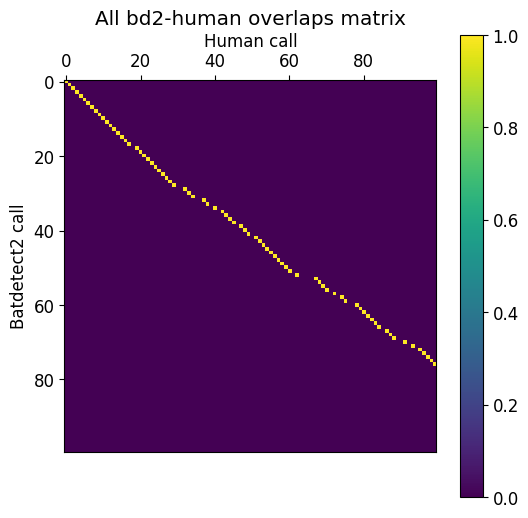

In [279]:
fig, ax = plt.subplots(1, 1, figsize=(6,6))
plt.rcParams.update({'font.size':12})

ax.set_title('All bd2-human overlaps matrix')
im = ax.imshow((association_matrix[np.logical_or.reduce(association_matrix, axis=1),:])[:100,:100])
ax.set_xlabel('Human call')
ax.xaxis.set_label_position('top')
ax.set_ylabel('Batdetect2 call')
ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
fig.colorbar(im, orientation='vertical')

plt.show()

In [51]:
save_loc_reduced_overlaps = Path(f"bd2__{threshold_tag}_chunksize{int(args['chunk_size'])}_{wav_filename}_REDUCED_OVERLAPS.csv")
filepath_reduced_overlaps = bd2_dets_save_dir / save_loc_reduced_overlaps
batdetect2_df_file_reduced_overlaps = pd.read_csv(filepath_reduced_overlaps, sep=',', index_col=0)
batdetect2_df_file_reduced_overlaps.rename(columns={'KMEANS_CLASSES':'freq_group'}, inplace=True)

In [52]:
batdetect2_subset_reduced_overlaps = batdetect2_df_file_reduced_overlaps[:].copy()
human_annotations_subset = bd2_human_df_file[:].copy()
dist_matrix = np.zeros((len(batdetect2_subset_reduced_overlaps), len(human_annotations_subset)))
association_matrix = np.zeros((len(batdetect2_subset_reduced_overlaps), len(human_annotations_subset)), dtype='bool')
collect_human = pd.DataFrame()
collect_bd2 = pd.DataFrame()
for index in range(len(batdetect2_subset_reduced_overlaps)):
    batdetect2_row = batdetect2_subset_reduced_overlaps.iloc[index]
    dist_to_all_calls = ((human_annotations_subset['peak_frequency_time'] - batdetect2_row['peak_frequency_time_SPECTROGRAM']).values)
    dist_matrix[index,:] = dist_to_all_calls
 
    dist_to_all_calls[np.abs(dist_to_all_calls)>=0.001] = 1
    dist_to_all_calls[np.abs(dist_to_all_calls)<0.001] = 0
    if np.abs(dist_to_all_calls-1).sum() > 1:
        collect_human = pd.concat([collect_human, human_annotations_subset[dist_to_all_calls<0.5]])
        collect_bd2 = pd.concat([collect_bd2, pd.DataFrame(batdetect2_row).T])

    association_matrix[index,:] = ~dist_to_all_calls.astype('bool')

human_bd2_true_positives_from_no_overlaps_data = human_annotations_subset.loc[np.logical_or.reduce(association_matrix, axis=0)]
bd2_false_negatives_from_no_overlaps_data = human_annotations_subset.loc[~(np.logical_or.reduce(association_matrix, axis=0))]
bd2_true_positives_from_no_overlaps_data = batdetect2_subset_reduced_overlaps.loc[np.logical_or.reduce(association_matrix, axis=1)]
bd2_false_positives_from_no_overlaps_data = batdetect2_subset_reduced_overlaps.loc[~(np.logical_or.reduce(association_matrix, axis=1))]
print(len(human_bd2_true_positives_from_no_overlaps_data), len(bd2_false_negatives_from_no_overlaps_data), 
      len(bd2_true_positives_from_no_overlaps_data), len(bd2_false_positives_from_no_overlaps_data))

3715 691 3709 56711


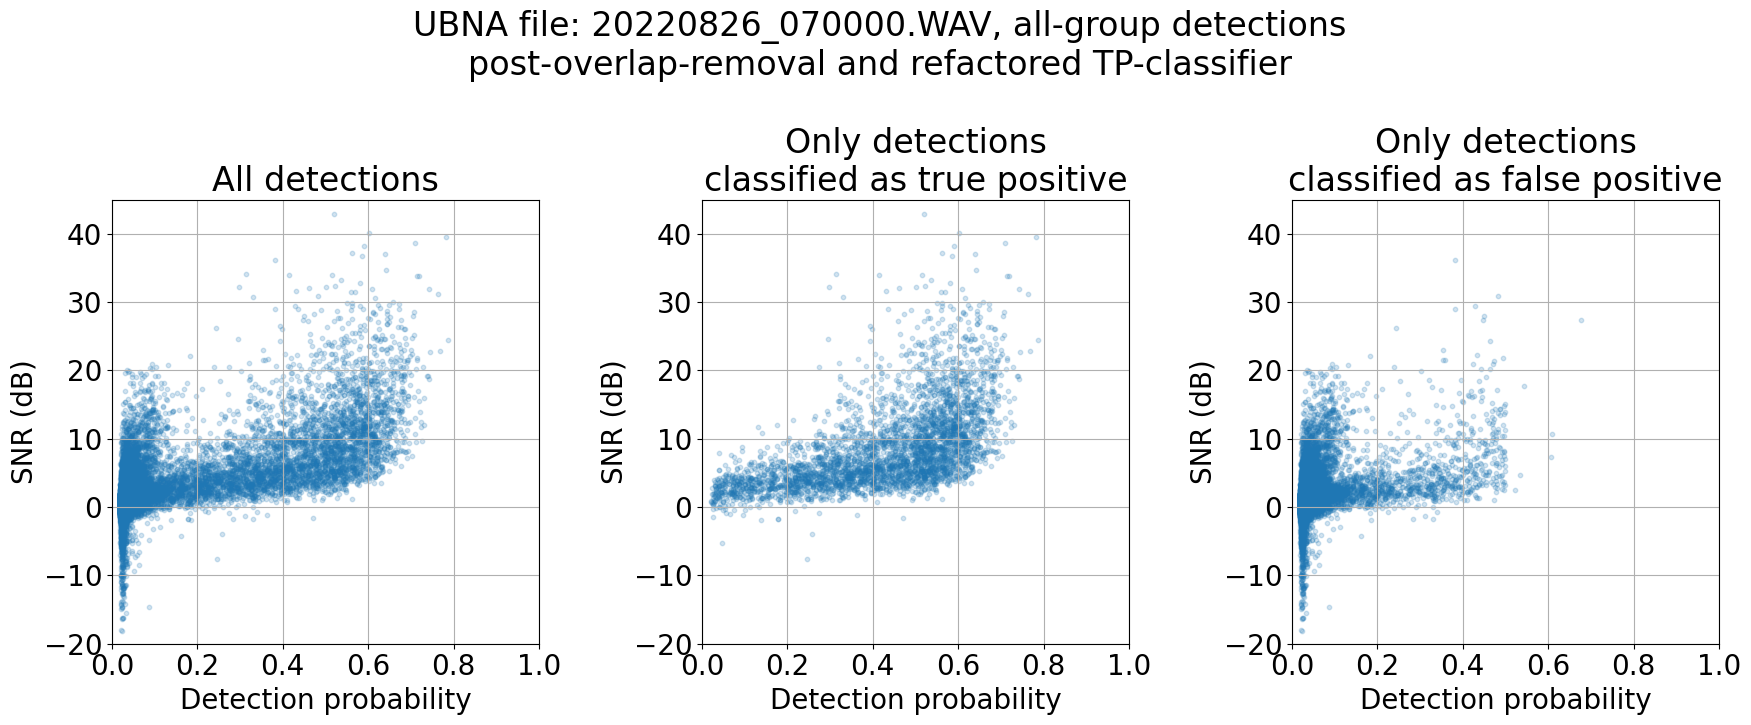

In [54]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18,7.5))
plt.rcParams.update({'font.size':20})

fig.suptitle(f'UBNA file: {wav_filename}.WAV, all-group detections\npost-overlap-removal and refactored TP-classifier')

ax = ax1
ax.set_title(f'All detections')
ax.scatter(batdetect2_df_file_reduced_overlaps['det_prob'].values, 
            batdetect2_df_file_reduced_overlaps['SNR'].values,
            alpha=0.2, s=10)
ax.grid(which='both')
ax.set_xlabel('Detection probability')
ax.set_ylabel('SNR (dB)')
ax.set_xlim(0, 1.0)
ax.set_ylim(-20, 45.0)

ax = ax2
ax.set_title(f'Only detections\nclassified as true positive')
ax.scatter(bd2_true_positives_from_no_overlaps_data['det_prob'].values, 
            bd2_true_positives_from_no_overlaps_data['SNR'].values,
            alpha=0.2, s=10)
ax.grid(which='both')
ax.set_xlabel('Detection probability')
ax.set_ylabel('SNR (dB)')
ax.set_xlim(0, 1.0)
ax.set_ylim(-20, 45.0)

ax = ax3
ax.set_title(f'Only detections\nclassified as false positive')
ax.scatter(bd2_false_positives_from_no_overlaps_data['det_prob'].values, 
            bd2_false_positives_from_no_overlaps_data['SNR'].values,
            alpha=0.2, s=10)
ax.grid(which='both')
ax.set_xlabel('Detection probability')
ax.set_ylabel('SNR (dB)')
ax.set_xlim(0, 1.0)
ax.set_ylim(-20, 45.0)


fig.tight_layout()
plt.show()

In [70]:
lf_batdetect2_subset_reduced_overlaps = batdetect2_df_file_reduced_overlaps[batdetect2_df_file_reduced_overlaps['freq_group']=='LF']
lf_batdetect2_subset_reduced_overlaps = lf_batdetect2_subset_reduced_overlaps[lf_batdetect2_subset_reduced_overlaps['det_prob']>=0.2].copy()
lf_human_annotations_subset = bd2_human_df_file[bd2_human_df_file['freq_group']=='LF'][:].copy()

dist_matrix = np.zeros((len(lf_batdetect2_subset_reduced_overlaps), len(lf_human_annotations_subset)))
association_matrix = np.zeros((len(lf_batdetect2_subset_reduced_overlaps), len(lf_human_annotations_subset)), dtype='bool')
collect_human = pd.DataFrame()
collect_bd2 = pd.DataFrame()
for index in range(len(lf_batdetect2_subset_reduced_overlaps)):
    batdetect2_row = lf_batdetect2_subset_reduced_overlaps.iloc[index]
    dist_to_all_calls = ((lf_human_annotations_subset['peak_frequency_time'] - batdetect2_row['peak_frequency_time_SPECTROGRAM']).values)
    dist_matrix[index,:] = dist_to_all_calls
 
    dist_to_all_calls[np.abs(dist_to_all_calls)>=0.001] = 1
    dist_to_all_calls[np.abs(dist_to_all_calls)<0.001] = 0
    if np.abs(dist_to_all_calls-1).sum() > 1:
        collect_human = pd.concat([collect_human, lf_human_annotations_subset[dist_to_all_calls<0.5]])
        collect_bd2 = pd.concat([collect_bd2, pd.DataFrame(batdetect2_row).T])

    association_matrix[index,:] = ~dist_to_all_calls.astype('bool')

lf_human_bd2_true_positives_from_no_overlaps_data = lf_human_annotations_subset.loc[np.logical_or.reduce(association_matrix, axis=0)]
lf_bd2_false_negatives_from_no_overlaps_data = lf_human_annotations_subset.loc[~(np.logical_or.reduce(association_matrix, axis=0))]
lf_bd2_true_positives_from_no_overlaps_data = lf_batdetect2_subset_reduced_overlaps.loc[np.logical_or.reduce(association_matrix, axis=1)]
lf_bd2_false_positives_from_no_overlaps_data = lf_batdetect2_subset_reduced_overlaps.loc[~(np.logical_or.reduce(association_matrix, axis=1))]
print(len(lf_human_bd2_true_positives_from_no_overlaps_data), len(lf_bd2_false_negatives_from_no_overlaps_data), 
      len(lf_bd2_true_positives_from_no_overlaps_data), len(lf_bd2_false_positives_from_no_overlaps_data))

646 492 646 302


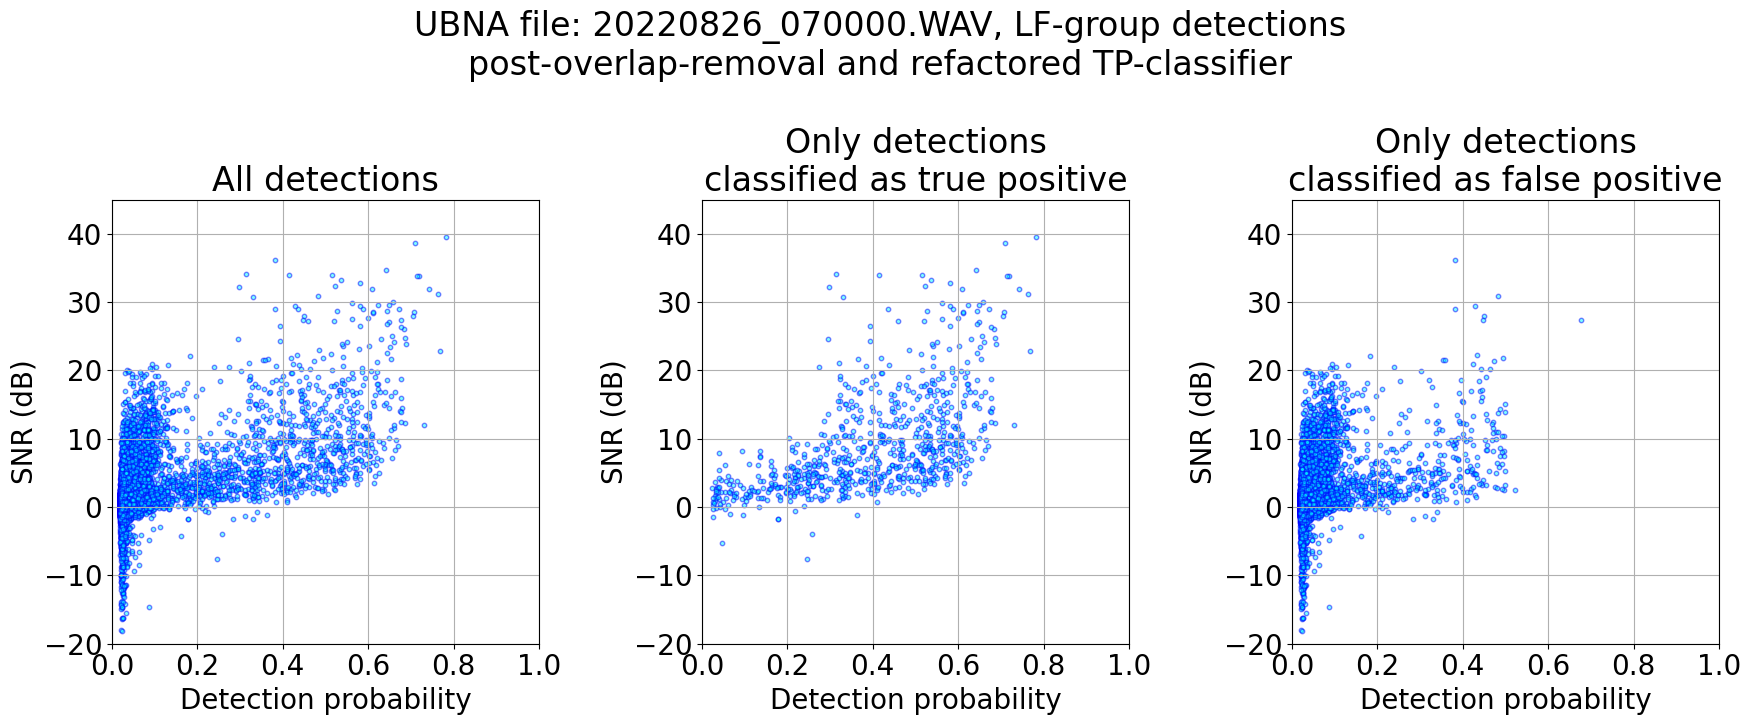

In [56]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18,7.5))
plt.rcParams.update({'font.size':20})

fig.suptitle(f'UBNA file: {wav_filename}.WAV, LF-group detections\npost-overlap-removal and refactored TP-classifier')

ax = ax1
ax.set_title(f'All detections')
ax.scatter(lf_batdetect2_subset_reduced_overlaps['det_prob'].values, 
            lf_batdetect2_subset_reduced_overlaps['SNR'].values,
            alpha=0.5, s=10, facecolor='cyan', edgecolor='blue')
ax.grid(which='both')
ax.set_xlabel('Detection probability')
ax.set_ylabel('SNR (dB)')
ax.set_xlim(0, 1.0)
ax.set_ylim(-20, 45.0)

ax = ax2
ax.set_title(f'Only detections\nclassified as true positive')
ax.scatter(lf_bd2_true_positives_from_no_overlaps_data['det_prob'].values, 
            lf_bd2_true_positives_from_no_overlaps_data['SNR'].values,
            alpha=0.5, s=10, facecolor='cyan', edgecolor='blue')
ax.grid(which='both')
ax.set_xlabel('Detection probability')
ax.set_ylabel('SNR (dB)')
ax.set_xlim(0, 1.0)
ax.set_ylim(-20, 45.0)

ax = ax3
ax.set_title(f'Only detections\nclassified as false positive')
ax.scatter(lf_bd2_false_positives_from_no_overlaps_data['det_prob'].values, 
            lf_bd2_false_positives_from_no_overlaps_data['SNR'].values,
            alpha=0.5, s=10, facecolor='cyan', edgecolor='blue')
ax.grid(which='both')
ax.set_xlabel('Detection probability')
ax.set_ylabel('SNR (dB)')
ax.set_xlim(0, 1.0)
ax.set_ylim(-20, 45.0)


fig.tight_layout()
plt.show()

In [66]:
lf_bd2_true_positives_from_no_overlaps_data[lf_bd2_true_positives_from_no_overlaps_data['det_prob']>=0.2]

,freq_group,peak_frequency_time_SPECTROGRAM,peak_frequency_SPECTROGRAM,peak_frequency_WELCH,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file
1519,LF,31.196967,24750.0,24000.0,1.052236,31.1865,31.2022,23750,29512,Nyctalus leisleri,0.138,0.322,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
1632,LF,32.622300,26250.0,25920.0,5.033592,32.6175,32.6342,24609,28640,Nyctalus leisleri,0.365,0.571,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
1666,LF,33.093733,25500.0,25920.0,3.818196,33.0855,33.1011,24609,28287,Nyctalus leisleri,0.215,0.370,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
1695,LF,33.496567,25500.0,25920.0,4.136854,33.4915,33.5056,24609,28405,Nyctalus leisleri,0.234,0.416,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
1716,LF,33.788467,24000.0,24960.0,4.613169,33.7805,33.7987,24609,28572,Nyctalus leisleri,0.118,0.226,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61333,LF,1190.773800,25500.0,25920.0,7.763690,1190.7575,1190.7802,25468,29020,Nyctalus leisleri,0.144,0.238,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
61364,LF,1191.425533,26250.0,25920.0,4.976283,1191.4205,1191.4393,23750,28813,Nyctalus leisleri,0.159,0.335,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
61412,LF,1192.074833,24750.0,25920.0,5.484776,1192.0625,1192.0810,24609,29689,Eptesicus serotinus,0.103,0.223,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
61484,LF,1192.989100,26250.0,24960.0,3.116921,1192.9835,1193.0029,24609,28014,Nyctalus leisleri,0.178,0.260,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...


In [68]:
lf_bd2_false_positives_from_no_overlaps_data[lf_bd2_false_positives_from_no_overlaps_data['det_prob']>=0.2]

,freq_group,peak_frequency_time_SPECTROGRAM,peak_frequency_SPECTROGRAM,peak_frequency_WELCH,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file
1556,LF,31.769033,24750.0,24960.0,1.232003,31.7585,31.7753,24609,29107,Nyctalus leisleri,0.103,0.242,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
1739,LF,34.222100,24000.0,25920.0,2.106444,34.2045,34.2224,24609,28639,Nyctalus leisleri,0.103,0.211,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
1818,LF,35.916733,26250.0,25920.0,9.152188,35.9125,35.9321,25468,28460,Nyctalus leisleri,0.273,0.345,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
1903,LF,37.638000,24000.0,24000.0,4.010468,37.6205,37.6385,23750,29345,Nyctalus leisleri,0.207,0.385,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
1931,LF,38.357567,24000.0,24000.0,5.616124,38.3505,38.3696,22890,28231,Nyctalus leisleri,0.234,0.392,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68243,LF,1339.881900,20250.0,20160.0,18.394567,1339.8795,1339.8846,16875,33443,Plecotus austriacus,0.154,0.254,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
74316,LF,1461.684533,26250.0,25920.0,5.168150,1461.6635,1461.6873,24609,28299,Nyctalus leisleri,0.211,0.304,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
74330,LF,1461.852767,24750.0,25920.0,5.127812,1461.8375,1461.8589,24609,28422,Nyctalus leisleri,0.141,0.210,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
74366,LF,1462.552833,25500.0,25920.0,5.359916,1462.5435,1462.5580,25468,30697,Nyctalus leisleri,0.176,0.285,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...


In [61]:
len(lf_bd2_false_negatives_from_no_overlaps_data)

381

In [19]:
hf_batdetect2_subset_reduced_overlaps = batdetect2_df_file_reduced_overlaps[batdetect2_df_file_reduced_overlaps['freq_group']=='HF'][:].copy()
hf_human_annotations_subset = bd2_human_df_file[bd2_human_df_file['freq_group']=='HF'][:].copy()

dist_matrix = np.zeros((len(hf_batdetect2_subset_reduced_overlaps), len(hf_human_annotations_subset)))
association_matrix = np.zeros((len(hf_batdetect2_subset_reduced_overlaps), len(hf_human_annotations_subset)), dtype='bool')
collect_human = pd.DataFrame()
collect_bd2 = pd.DataFrame()
for index in range(len(hf_batdetect2_subset_reduced_overlaps)):
    batdetect2_row = hf_batdetect2_subset_reduced_overlaps.iloc[index]
    dist_to_all_calls = ((hf_human_annotations_subset['peak_frequency_time'] - batdetect2_row['peak_frequency_time_SPECTROGRAM']).values)
    dist_matrix[index,:] = dist_to_all_calls
 
    dist_to_all_calls[np.abs(dist_to_all_calls)>=0.001] = 1
    dist_to_all_calls[np.abs(dist_to_all_calls)<0.001] = 0
    if np.abs(dist_to_all_calls-1).sum() > 1:
        collect_human = pd.concat([collect_human, hf_human_annotations_subset[dist_to_all_calls<0.5]])
        collect_bd2 = pd.concat([collect_bd2, pd.DataFrame(batdetect2_row).T])

    association_matrix[index,:] = ~dist_to_all_calls.astype('bool')

hf_human_bd2_true_positives_from_no_overlaps_data = hf_human_annotations_subset.loc[np.logical_or.reduce(association_matrix, axis=0)]
hf_bd2_false_negatives_from_no_overlaps_data = hf_human_annotations_subset.loc[~(np.logical_or.reduce(association_matrix, axis=0))]
hf_bd2_true_positives_from_no_overlaps_data = hf_batdetect2_subset_reduced_overlaps.loc[np.logical_or.reduce(association_matrix, axis=1)]
hf_bd2_false_positives_from_no_overlaps_data = hf_batdetect2_subset_reduced_overlaps.loc[~(np.logical_or.reduce(association_matrix, axis=1))]
print(len(hf_human_bd2_true_positives_from_no_overlaps_data), len(hf_bd2_false_negatives_from_no_overlaps_data), 
      len(hf_bd2_true_positives_from_no_overlaps_data), len(hf_bd2_false_positives_from_no_overlaps_data))

2941 327 2941 23615


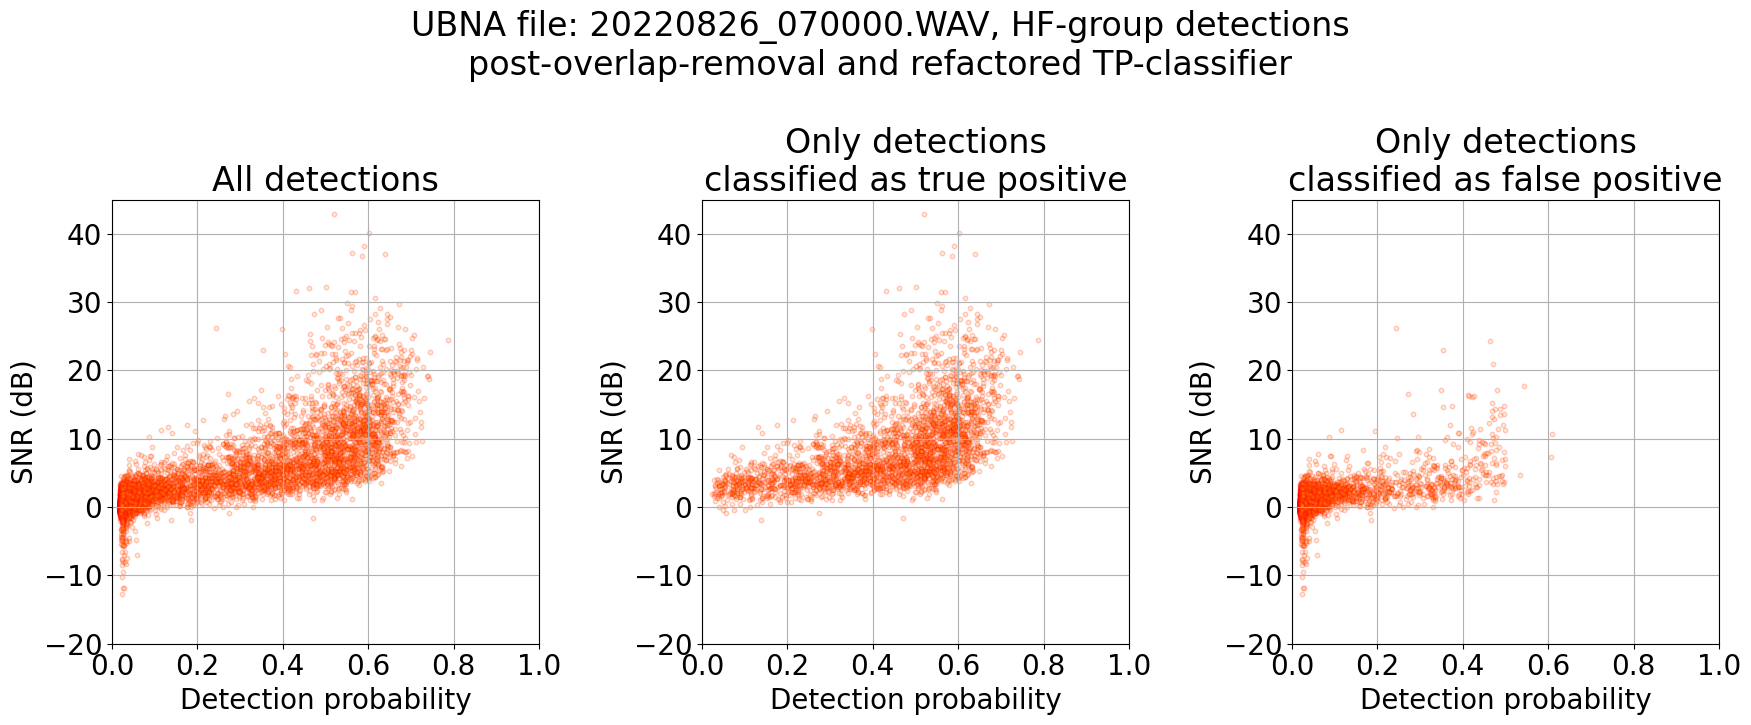

In [20]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18,7.5))
plt.rcParams.update({'font.size':20})

fig.suptitle(f'UBNA file: {wav_filename}.WAV, HF-group detections\npost-overlap-removal and refactored TP-classifier')

ax = ax1
ax.set_title(f'All detections')
ax.scatter(hf_batdetect2_subset_reduced_overlaps['det_prob'].values, 
            hf_batdetect2_subset_reduced_overlaps['SNR'].values,
            alpha=0.2, s=10, facecolor='orange', edgecolor='red')
ax.grid(which='both')
ax.set_xlabel('Detection probability')
ax.set_ylabel('SNR (dB)')
ax.set_xlim(0, 1.0)
ax.set_ylim(-20, 45.0)

ax = ax2
ax.set_title(f'Only detections\nclassified as true positive')
ax.scatter(hf_bd2_true_positives_from_no_overlaps_data['det_prob'].values, 
            hf_bd2_true_positives_from_no_overlaps_data['SNR'].values,
            alpha=0.2, s=10, facecolor='orange', edgecolor='red')
ax.grid(which='both')
ax.set_xlabel('Detection probability')
ax.set_ylabel('SNR (dB)')
ax.set_xlim(0, 1.0)
ax.set_ylim(-20, 45.0)

ax = ax3
ax.set_title(f'Only detections\nclassified as false positive')
ax.scatter(hf_bd2_false_positives_from_no_overlaps_data['det_prob'].values, 
            hf_bd2_false_positives_from_no_overlaps_data['SNR'].values,
            alpha=0.2, s=10, facecolor='orange', edgecolor='red')
ax.grid(which='both')
ax.set_xlabel('Detection probability')
ax.set_ylabel('SNR (dB)')
ax.set_xlim(0, 1.0)
ax.set_ylim(-20, 45.0)


fig.tight_layout()
plt.show()

In [21]:
all_files_batdetct2_df_reduced_overlaps = pd.DataFrame()
lf_all_files_batdetct2_df_reduced_overlaps = pd.DataFrame()
hf_all_files_batdetct2_df_reduced_overlaps = pd.DataFrame()

all_files_batdetct2_df_true_positives_reduced_overlaps = pd.DataFrame()
lf_all_files_batdetct2_df_true_positives_reduced_overlaps = pd.DataFrame()
hf_all_files_batdetct2_df_true_positives_reduced_overlaps = pd.DataFrame()

all_files_batdetct2_df_false_positives_reduced_overlaps = pd.DataFrame()
lf_all_files_batdetct2_df_false_positives_reduced_overlaps = pd.DataFrame()
hf_all_files_batdetct2_df_false_positives_reduced_overlaps = pd.DataFrame()
for file_num, file_key in enumerate(file_keys):
    wav_filename = file_key
    site = file_sites[file_key]
    plot_file = Path(f'{raventxt_human_files_dir}/{wav_filename}.WAV')
    raventxt_human_filename = f'{wav_filename}_manually_verified_by_AK_with_groups'

    snr_included_ravenpro_human_txt = pd.read_csv(f'{raventxt_human_files_dir}/{raventxt_human_filename}_ravenpro_SNR_aditya_SNR_and_peakfreqtime.txt', sep=sep)
    bd2_human_df_file = snr_included_ravenpro_human_txt.copy()
    bd2_human_df_file = bd2_human_df_file.drop(columns=['Selection', 'View', 'Channel'])
    bd2_human_df_file.rename(columns={'Begin Time (s)':'start_time',
                                'End Time (s)':'end_time',
                                'Low Freq (Hz)':'low_freq',
                                'High Freq (Hz)':'high_freq',
                                'Delta Time (s)':'delta_time_s',
                                'Manually-Verified Phonic Group':'freq_group',
                                'SNR NIST Quick (dB)':'snr_nist_quick_dB'}, inplace=True)
    bd2_human_df_file.sort_values('start_time', inplace=True)
    bd2_human_df_file = bd2_human_df_file.reset_index(drop=True)
    lf_bd2_human_df_file = bd2_human_df_file[bd2_human_df_file['freq_group']=='LF'].copy()
    hf_bd2_human_df_file = bd2_human_df_file[bd2_human_df_file['freq_group']=='HF'].copy()

    args = dict()
    args['chunk_size'] = 2
    args['detection_threshold'] = 0.00
    ones = int(args['detection_threshold'])
    decimals = int(int(100*(args['detection_threshold'])) % 100)
    threshold_tag = f"threshold{ones}p{decimals:02}"
    save_loc_reduced_overlaps = Path(f"bd2__{threshold_tag}_chunksize{int(args['chunk_size'])}_{wav_filename}_REDUCED_OVERLAPS.csv")
    filepath_reduced_overlaps = bd2_dets_save_dir / save_loc_reduced_overlaps
    batdetect2_df_file_reduced_overlaps = pd.read_csv(filepath_reduced_overlaps, sep=',', index_col=0)
    batdetect2_df_file_reduced_overlaps.rename(columns={'KMEANS_CLASSES':'freq_group'}, inplace=True)
    lf_batdetect2_df_file_reduced_overlaps = batdetect2_df_file_reduced_overlaps[batdetect2_df_file_reduced_overlaps['freq_group']=='LF'].copy()
    hf_batdetect2_df_file_reduced_overlaps = batdetect2_df_file_reduced_overlaps[batdetect2_df_file_reduced_overlaps['freq_group']=='HF'].copy()

    all_files_batdetct2_df_reduced_overlaps = pd.concat([all_files_batdetct2_df_reduced_overlaps, batdetect2_df_file_reduced_overlaps])
    lf_all_files_batdetct2_df_reduced_overlaps = pd.concat([lf_all_files_batdetct2_df_reduced_overlaps, lf_batdetect2_df_file_reduced_overlaps])
    hf_all_files_batdetct2_df_reduced_overlaps = pd.concat([hf_all_files_batdetct2_df_reduced_overlaps, hf_batdetect2_df_file_reduced_overlaps])

    true_positives_batdetect2_df_file_reduced_overlaps, false_positives_batdetect2_df_file_reduced_overlaps = return_true_positives_using_human_df(bd2_human_df_file, 
                                                                                                              batdetect2_df_file_reduced_overlaps, debug=False)
    lf_true_positives_batdetect2_df_file_reduced_overlaps, lf_false_positives_batdetect2_df_file_reduced_overlaps = return_true_positives_using_human_df(lf_bd2_human_df_file, 
                                                                                                              lf_batdetect2_df_file_reduced_overlaps, debug=False)
    hf_true_positives_batdetect2_df_file_reduced_overlaps, hf_false_positives_batdetect2_df_file_reduced_overlaps = return_true_positives_using_human_df(hf_bd2_human_df_file, 
                                                                                                              hf_batdetect2_df_file_reduced_overlaps, debug=False)
    
    all_files_batdetct2_df_true_positives_reduced_overlaps = pd.concat([all_files_batdetct2_df_true_positives_reduced_overlaps, 
                                                                        true_positives_batdetect2_df_file_reduced_overlaps])
    lf_all_files_batdetct2_df_true_positives_reduced_overlaps = pd.concat([lf_all_files_batdetct2_df_true_positives_reduced_overlaps, 
                                                                        lf_true_positives_batdetect2_df_file_reduced_overlaps])
    hf_all_files_batdetct2_df_true_positives_reduced_overlaps = pd.concat([hf_all_files_batdetct2_df_true_positives_reduced_overlaps, 
                                                                        hf_true_positives_batdetect2_df_file_reduced_overlaps])
    
    all_files_batdetct2_df_false_positives_reduced_overlaps = pd.concat([all_files_batdetct2_df_false_positives_reduced_overlaps, 
                                                                        false_positives_batdetect2_df_file_reduced_overlaps])
    lf_all_files_batdetct2_df_false_positives_reduced_overlaps = pd.concat([lf_all_files_batdetct2_df_false_positives_reduced_overlaps, 
                                                                        lf_false_positives_batdetect2_df_file_reduced_overlaps])
    hf_all_files_batdetct2_df_false_positives_reduced_overlaps = pd.concat([hf_all_files_batdetct2_df_false_positives_reduced_overlaps, 
                                                                        hf_false_positives_batdetect2_df_file_reduced_overlaps])

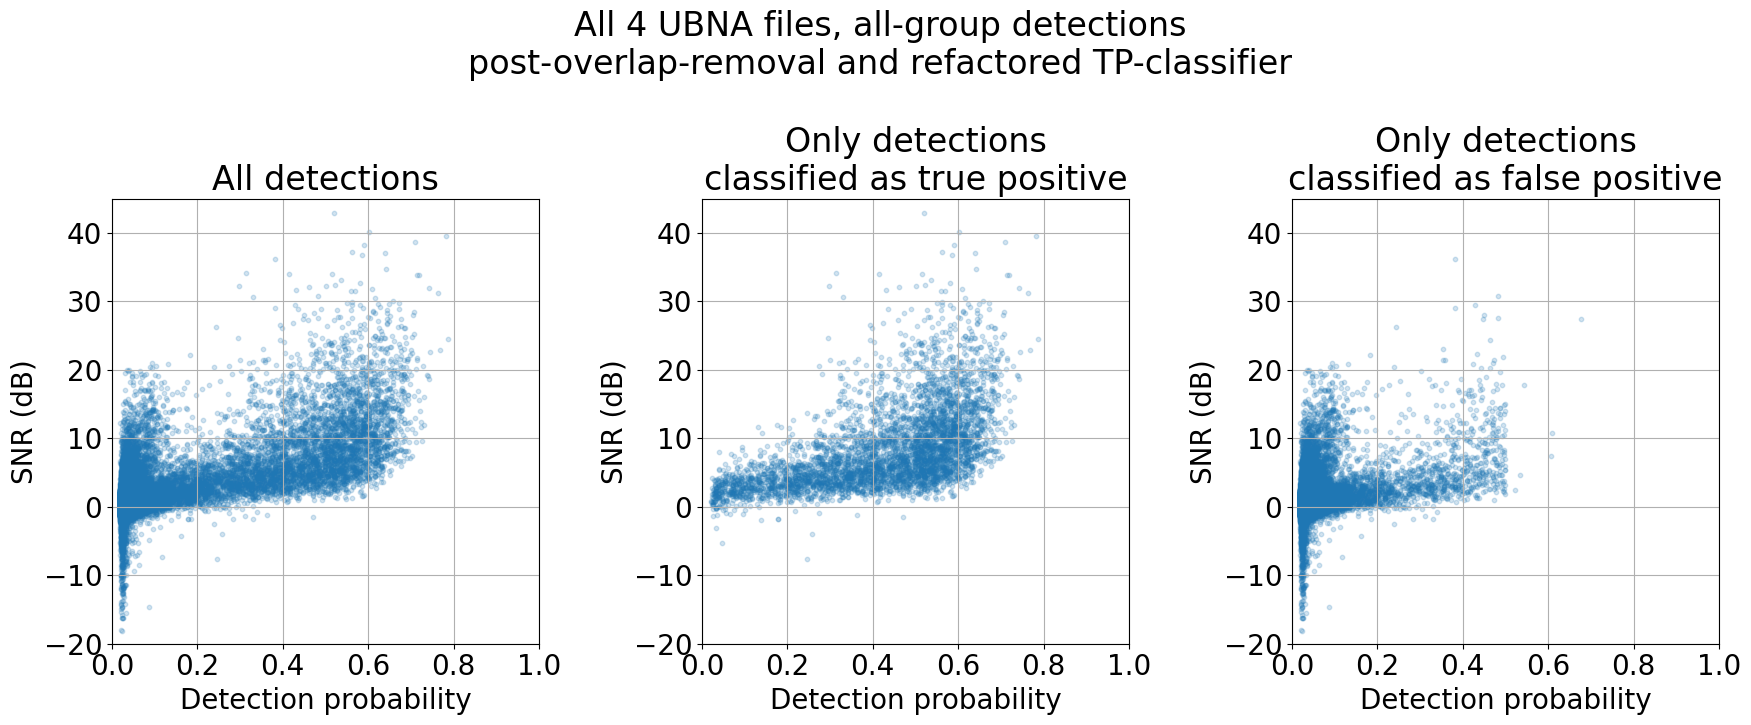

In [26]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18,7.5))
plt.rcParams.update({'font.size':20})

fig.suptitle(f'All 4 UBNA files, all-group detections\npost-overlap-removal and refactored TP-classifier')

ax = ax1
ax.set_title(f'All detections')
ax.scatter(all_files_batdetct2_df_reduced_overlaps['det_prob'].values, 
            all_files_batdetct2_df_reduced_overlaps['SNR'].values,
            alpha=0.2, s=10)
ax.grid(which='both')
ax.set_xlabel('Detection probability')
ax.set_ylabel('SNR (dB)')
ax.set_xlim(0, 1.0)
ax.set_ylim(-20, 45.0)

ax = ax2
ax.set_title(f'Only detections\nclassified as true positive')
ax.scatter(all_files_batdetct2_df_true_positives_reduced_overlaps['det_prob'].values, 
            all_files_batdetct2_df_true_positives_reduced_overlaps['SNR'].values,
            alpha=0.2, s=10)
ax.grid(which='both')
ax.set_xlabel('Detection probability')
ax.set_ylabel('SNR (dB)')
ax.set_xlim(0, 1.0)
ax.set_ylim(-20, 45.0)

ax = ax3
ax.set_title(f'Only detections\nclassified as false positive')
ax.scatter(all_files_batdetct2_df_false_positives_reduced_overlaps['det_prob'].values, 
            all_files_batdetct2_df_false_positives_reduced_overlaps['SNR'].values,
            alpha=0.2, s=10)
ax.grid(which='both')
ax.set_xlabel('Detection probability')
ax.set_ylabel('SNR (dB)')
ax.set_xlim(0, 1.0)
ax.set_ylim(-20, 45.0)


fig.tight_layout()
plt.show()

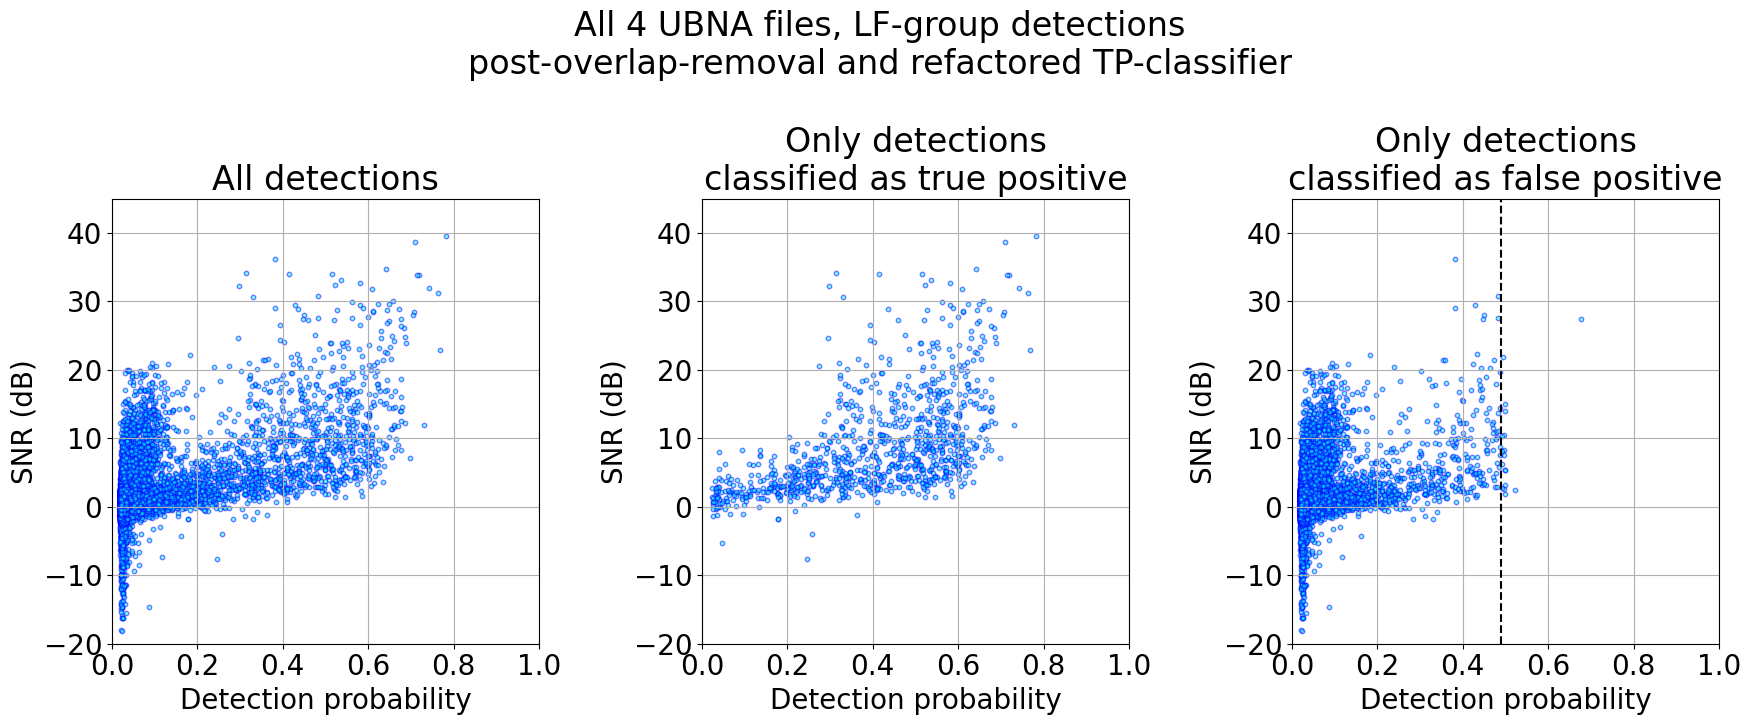

In [209]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18,7.5))
plt.rcParams.update({'font.size':20})

fig.suptitle(f'All 4 UBNA files, LF-group detections\npost-overlap-removal and refactored TP-classifier')

ax = ax1
ax.set_title(f'All detections')
ax.scatter(lf_all_files_batdetct2_df_reduced_overlaps['det_prob'].values, 
            lf_all_files_batdetct2_df_reduced_overlaps['SNR'].values,
            alpha=0.5, s=10, facecolor='cyan', edgecolor='blue')
ax.grid(which='both')
ax.set_xlabel('Detection probability')
ax.set_ylabel('SNR (dB)')
ax.set_xlim(0, 1.0)
ax.set_ylim(-20, 45.0)

ax = ax2
ax.set_title(f'Only detections\nclassified as true positive')
ax.scatter(lf_all_files_batdetct2_df_true_positives_reduced_overlaps['det_prob'].values, 
            lf_all_files_batdetct2_df_true_positives_reduced_overlaps['SNR'].values,
            alpha=0.5, s=10, facecolor='cyan', edgecolor='blue')
ax.grid(which='both')
ax.set_xlabel('Detection probability')
ax.set_ylabel('SNR (dB)')
ax.set_xlim(0, 1.0)
ax.set_ylim(-20, 45.0)

ax = ax3
ax.set_title(f'Only detections\nclassified as false positive')
ax.scatter(lf_all_files_batdetct2_df_false_positives_reduced_overlaps['det_prob'].values, 
            lf_all_files_batdetct2_df_false_positives_reduced_overlaps['SNR'].values,
            alpha=0.5, s=10, facecolor='cyan', edgecolor='blue')
ax.grid(which='both')
ax.axvline(x=0.49, linestyle='dashed', color='k')
ax.set_xlabel('Detection probability')
ax.set_ylabel('SNR (dB)')
ax.set_xlim(0, 1.0)
ax.set_ylim(-20, 45.0)


fig.tight_layout()
plt.show()

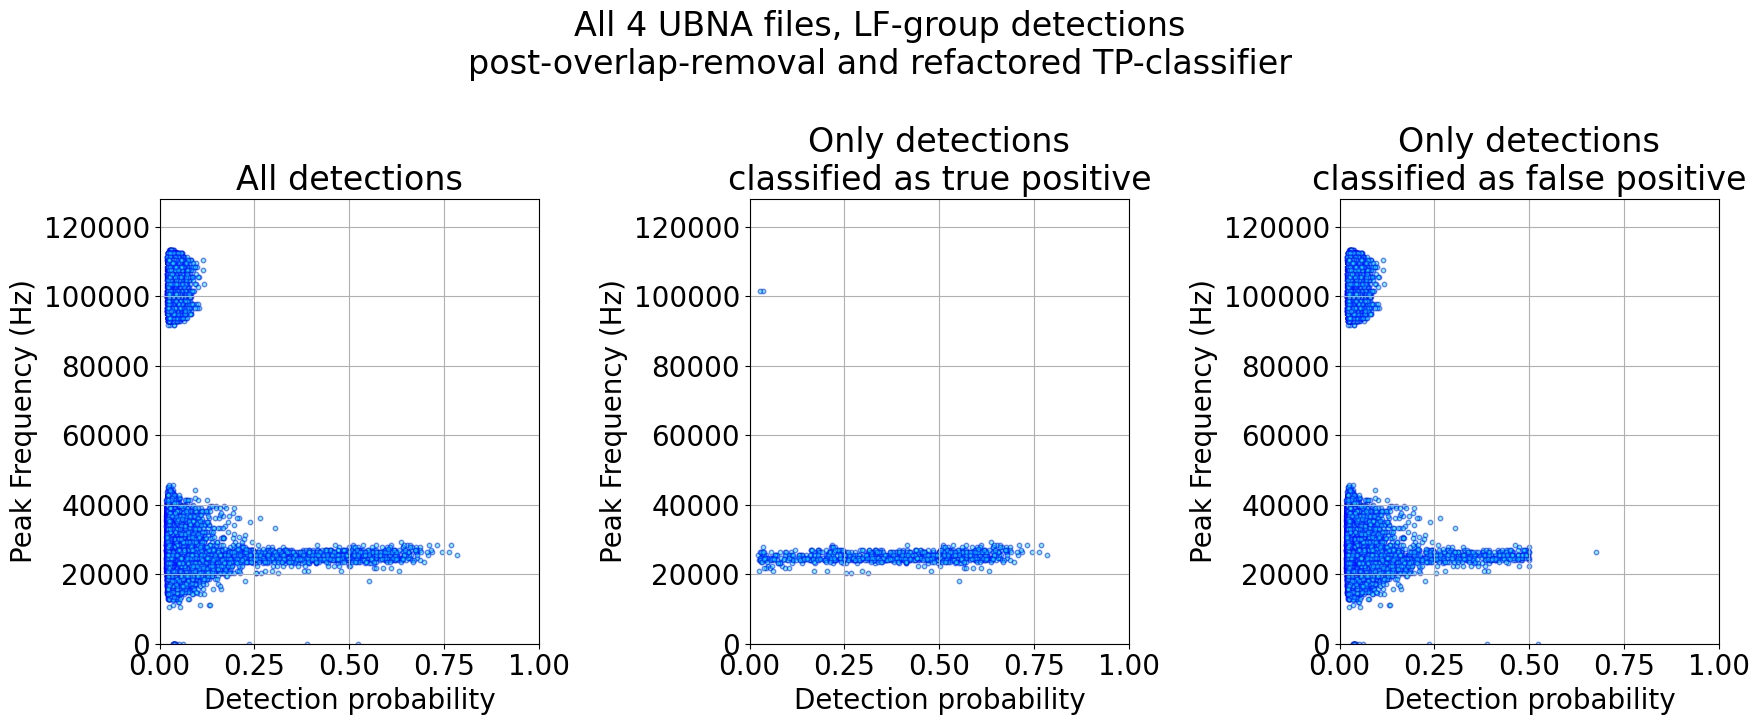

In [105]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18,7.5))
plt.rcParams.update({'font.size':20})

fig.suptitle(f'All 4 UBNA files, LF-group detections\npost-overlap-removal and refactored TP-classifier')

ax = ax1
ax.set_title(f'All detections')
ax.scatter(lf_all_files_batdetct2_df_reduced_overlaps['det_prob'].values, 
            lf_all_files_batdetct2_df_reduced_overlaps['peak_frequency_SPECTROGRAM'].values,
            alpha=0.5, s=10, facecolor='cyan', edgecolor='blue')
ax.grid(which='both')
ax.set_xlabel('Detection probability')
ax.set_ylabel('Peak Frequency (Hz)')
ax.set_xlim(0, 1.0)
ax.set_ylim(0, 128000)

ax = ax2
ax.set_title(f'Only detections\nclassified as true positive')
ax.scatter(lf_all_files_batdetct2_df_true_positives_reduced_overlaps['det_prob'].values, 
            lf_all_files_batdetct2_df_true_positives_reduced_overlaps['peak_frequency_SPECTROGRAM'].values,
            alpha=0.5, s=10, facecolor='cyan', edgecolor='blue')
ax.grid(which='both')
ax.set_xlabel('Detection probability')
ax.set_ylabel('Peak Frequency (Hz)')
ax.set_xlim(0, 1.0)
ax.set_ylim(0, 128000)

ax = ax3
ax.set_title(f'Only detections\nclassified as false positive')
ax.scatter(lf_all_files_batdetct2_df_false_positives_reduced_overlaps['det_prob'].values, 
            lf_all_files_batdetct2_df_false_positives_reduced_overlaps['peak_frequency_SPECTROGRAM'].values,
            alpha=0.5, s=10, facecolor='cyan', edgecolor='blue')
ax.grid(which='both')
ax.set_xlabel('Detection probability')
ax.set_ylabel('Peak Frequency (Hz)')
ax.set_xlim(0, 1.0)
ax.set_ylim(0, 128000)


fig.tight_layout()
plt.show()

In [248]:
selections = lf_all_files_batdetct2_df_false_positives_reduced_overlaps[lf_all_files_batdetct2_df_false_positives_reduced_overlaps['det_prob']>0.49]
selections

,freq_group,peak_frequency_time_SPECTROGRAM,peak_frequency_SPECTROGRAM,peak_frequency_WELCH,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file
7986,LF,154.512433,26250.0000,25920.0,3.234682,154.5045,154.5169,24609,30094,Nyctalus leisleri,0.257,0.500,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
16821,LF,311.238600,26250.0000,25920.0,2.544830,311.2275,311.2449,25468,29868,Nyctalus leisleri,0.283,0.497,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
21264,LF,395.972133,24000.0000,24960.0,5.308883,395.9635,395.9787,23750,28694,Nyctalus leisleri,0.385,0.499,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
25118,LF,464.417300,24750.0000,24960.0,2.674338,464.4065,464.4207,24609,29531,Nyctalus leisleri,0.302,0.492,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
26591,LF,490.267733,24750.0000,24960.0,13.976294,490.2565,490.2726,24609,28608,Nyctalus leisleri,0.264,0.498,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
29540,LF,550.281300,26250.0000,25920.0,6.254773,550.2725,550.2887,24609,29491,Nyctalus leisleri,0.324,0.492,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
36877,LF,701.963300,25500.0000,25920.0,10.437344,701.9545,701.9742,23750,28444,Nyctalus leisleri,0.277,0.496,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
37415,LF,710.920333,24750.0000,24960.0,8.236994,710.9055,710.9250,24609,28071,Nyctalus leisleri,0.387,0.497,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
37853,LF,720.000667,0.0000,27840.0,2.494946,720.0085,720.0189,26328,32386,Nyctalus leisleri,0.249,0.522,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
37938,LF,721.948000,27000.0000,26880.0,21.892419,721.9405,721.9545,26328,30309,Nyctalus leisleri,0.301,0.495,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...


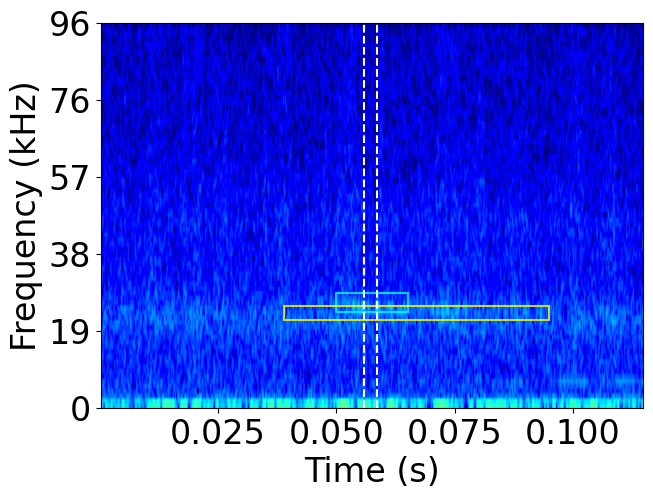

In [252]:
selection_row = selections.iloc[2]
input_file = Path(selection_row['input_file'])
file_name = input_file.name
file_path = Path(raventxt_human_files_dir) / file_name
audio_file = sf.SoundFile(file_path)
fs = audio_file.samplerate

file_selections = selections[selections['input_file']==str(input_file)]
file_true_positives = lf_all_files_batdetct2_df_true_positives_reduced_overlaps[lf_all_files_batdetct2_df_true_positives_reduced_overlaps['input_file']==str(input_file)]
raventxt_human_filename = f'{input_file.stem}_manually_verified_by_AK_with_groups'

snr_included_ravenpro_human_txt = pd.read_csv(f'{raventxt_human_files_dir}/{raventxt_human_filename}_ravenpro_SNR_aditya_SNR_and_peakfreqtime.txt', sep=sep)
bd2_human_df_file = snr_included_ravenpro_human_txt.copy()
bd2_human_df_file = bd2_human_df_file.drop(columns=['Selection', 'View', 'Channel'])
bd2_human_df_file.rename(columns={'Begin Time (s)':'start_time',
                            'End Time (s)':'end_time',
                            'Low Freq (Hz)':'low_freq',
                            'High Freq (Hz)':'high_freq',
                            'Delta Time (s)':'delta_time_s',
                            'Manually-Verified Phonic Group':'freq_group',
                            'SNR NIST Quick (dB)':'snr_nist_quick_dB'}, inplace=True)
bd2_human_df_file.sort_values('start_time', inplace=True)
bd2_human_df_file = bd2_human_df_file.reset_index(drop=True)

start = selection_row['start_time']-0.05
audio_file.seek(int(fs*(start)))
duration = (selection_row['end_time']-selection_row['start_time'])+0.1
audio_seg = audio_file.read(int(fs*duration))

plt.figure(figsize=(7, 5))
plt.rcParams.update({'font.size': 24})
plt.specgram(audio_seg, NFFT=156, Fs=fs, cmap='jet', vmin=-120, vmax=0)

ax = plt.gca()
plot_bd2fpdets = file_selections[(file_selections['start_time']>=start)&(file_selections['end_time']<=(start+duration))]
for i, row in plot_bd2fpdets.iterrows():
    rect = patches.Rectangle(((row['start_time'] - start), row['low_freq']), 
                    (row['end_time'] - row['start_time']), (row['high_freq'] - row['low_freq']), 
                    linewidth=1.5, edgecolor=FREQ_COLORS[row['freq_group']], facecolor='none', alpha=0.8)
    ax.add_patch(rect)
    ax.axvline(x=row['peak_frequency_time_SPECTROGRAM']-start, linestyle='dashed', color='w')

plot_humandets = bd2_human_df_file[(bd2_human_df_file['start_time']>=start)&(bd2_human_df_file['end_time']<=(start+duration))]
for i, row in plot_humandets.iterrows():
    rect = patches.Rectangle(((row['start_time'] - start), row['low_freq']), 
                    (row['end_time'] - row['start_time']), (row['high_freq'] - row['low_freq']), 
                    linewidth=1.5, edgecolor='yellow', facecolor='none', alpha=0.8)
    ax.add_patch(rect)
    ax.axvline(x=row['peak_frequency_time']-start, linestyle='dashed', color='w')

plot_bd2tpdets = file_true_positives[(file_true_positives['start_time']>=start)&(file_true_positives['end_time']<=(start+duration))]
for i, row in plot_bd2tpdets.iterrows():
    rect = patches.Rectangle(((row['start_time'] - start), row['low_freq']), 
                    (row['end_time'] - row['start_time']), (row['high_freq'] - row['low_freq']), 
                    linewidth=1.5, edgecolor='green', facecolor='none', alpha=0.8)
    ax.add_patch(rect)
    ax.axvline(x=row['peak_frequency_time_SPECTROGRAM']-start, linestyle='dashed', color='w')

plt.yticks(ticks=np.linspace(0, fs/2, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
plt.ylabel("Frequency (kHz)")
plt.xlabel("Time (s)")
plt.show()

In [110]:
selections = lf_all_files_batdetct2_df_true_positives_reduced_overlaps[lf_all_files_batdetct2_df_true_positives_reduced_overlaps['peak_frequency_SPECTROGRAM']>1e5]

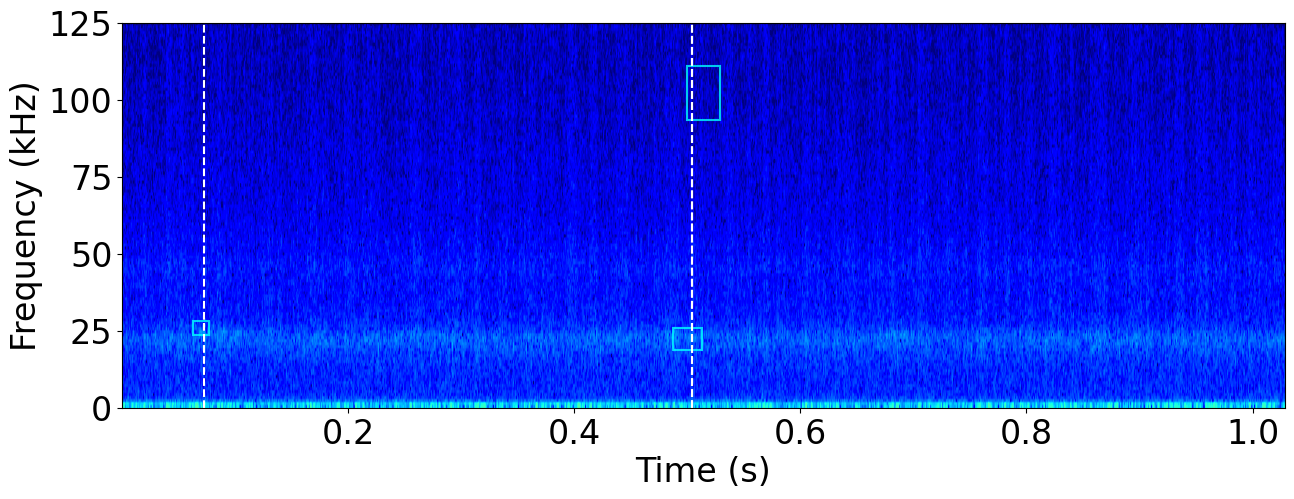

In [189]:
selection_row = selections.iloc[0]
input_file = Path(selection_row['input_file'])
file_name = input_file.name
file_path = Path(raventxt_human_files_dir) / file_name
audio_file = sf.SoundFile(file_path)
fs = audio_file.samplerate


raventxt_human_filename = f'{input_file.stem}_manually_verified_by_AK_with_groups'

snr_included_ravenpro_human_txt = pd.read_csv(f'{raventxt_human_files_dir}/{raventxt_human_filename}_ravenpro_SNR_aditya_SNR_and_peakfreqtime.txt', sep=sep)
bd2_human_df_file = snr_included_ravenpro_human_txt.copy()
bd2_human_df_file = bd2_human_df_file.drop(columns=['Selection', 'View', 'Channel'])
bd2_human_df_file.rename(columns={'Begin Time (s)':'start_time',
                            'End Time (s)':'end_time',
                            'Low Freq (Hz)':'low_freq',
                            'High Freq (Hz)':'high_freq',
                            'Delta Time (s)':'delta_time_s',
                            'Manually-Verified Phonic Group':'freq_group',
                            'SNR NIST Quick (dB)':'snr_nist_quick_dB'}, inplace=True)
bd2_human_df_file.sort_values('start_time', inplace=True)
bd2_human_df_file = bd2_human_df_file.reset_index(drop=True)

start = selection_row['start_time']-0.5
audio_file.seek(int(fs*(start)))
duration = (selection_row['end_time']-selection_row['start_time'])+1
audio_seg = audio_file.read(int(fs*duration))

plt.figure(figsize=(15, 5))
plt.rcParams.update({'font.size': 24})
plt.specgram(audio_seg, NFFT=256, Fs=fs, cmap='jet', vmin=-120, vmax=0)

ax = plt.gca()
plot_bd2dets = selections[(selections['start_time']>=start)&(selections['end_time']<=(start+duration))]
for i, row in plot_bd2dets.iterrows():
    rect = patches.Rectangle(((row['start_time'] - start), row['low_freq']), 
                    (row['end_time'] - row['start_time']), (row['high_freq'] - row['low_freq']), 
                    linewidth=1.5, edgecolor=FREQ_COLORS[row['freq_group']], facecolor='none', alpha=0.8)
    ax.add_patch(rect)
    ax.axvline(x=row['peak_frequency_time_SPECTROGRAM']-start, linestyle='dashed', color='w')

plot_humandets = bd2_human_df_file[(bd2_human_df_file['start_time']>=start)&(bd2_human_df_file['end_time']<=(start+duration))]
for i, row in plot_humandets.iterrows():
    rect = patches.Rectangle(((row['start_time'] - start), row['low_freq']), 
                    (row['end_time'] - row['start_time']), (row['high_freq'] - row['low_freq']), 
                    linewidth=1.5, edgecolor=FREQ_COLORS[row['freq_group']], facecolor='none', alpha=0.8)
    ax.add_patch(rect)
    ax.axvline(x=row['peak_frequency_time']-start, linestyle='dashed', color='w')

plt.yticks(ticks=np.linspace(0, fs/2, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
plt.ylabel("Frequency (kHz)")
plt.xlabel("Time (s)")
plt.show()

In [190]:
plot_bd2dets

,freq_group,peak_frequency_time_SPECTROGRAM,peak_frequency_SPECTROGRAM,peak_frequency_WELCH,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file
105913,LF,1082.73574,101562.5,95040.0,-1.214068,1082.7315,1082.7603,93359,110842,Rhinolophus hipposideros,0.035,0.035,-1,Echolocation,250000,/home/adkris/Documents/mila-human-wav-txt/2022...


In [191]:
plot_humandets

,start_time,end_time,low_freq,high_freq,snr_nist_quick_dB,class,class_prob,det_prob,individual,Annotation,input_file,Site name,Recover Folder,SD Card,confidency,freq_group,adityas_method_snr_dB,peak_frequency_time
43,1082.294500,1082.30880,23750.00,28156.000,13.87,Nyctalus leisleri,0.416,0.545,-1.0,Echolocation,/mnt/ubna_data_01/recover-20220728/UBNA_011/20...,Foliage,recover-20220728,11.0,NaN,LF,1.508093,1082.304280
44,1082.719039,1082.74469,18601.19,26041.667,12.28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,LF,1.423587,1082.735387


In [192]:
def get_section_of_call_in_file(detection, audio_file):
    fs = audio_file.samplerate
    num_frames = audio_file.frames
    file_length = num_frames/fs

    call_dur = (detection['end_time'] - detection['start_time'])
    pad = min(min(detection['start_time'] - call_dur, file_length - detection['end_time']), 0.006) / 3
    start = detection['start_time'] - call_dur - (3*pad)
    duration = ((2 * call_dur) + (4*pad))

    try:
        audio_file.seek(int(fs*start))
        audio_seg = audio_file.read(int(fs*duration))
        length_of_section = call_dur + (2*pad)
    except sf.LibsndfileError as e:
        print(f'Start time : {start} invalid, detection starts at {detection["start_time"]} in segment:{audio_file.name}')
        audio_seg = None
        length_of_section = 0

    return audio_seg, length_of_section, pad

In [193]:
selection_row

freq_group                                                                        LF
peak_frequency_time_SPECTROGRAM                                           1082.73574
peak_frequency_SPECTROGRAM                                                  101562.5
peak_frequency_WELCH                                                         95040.0
SNR                                                                        -1.214068
start_time                                                                 1082.7315
end_time                                                                   1082.7603
low_freq                                                                       93359
high_freq                                                                     110842
class                                                       Rhinolophus hipposideros
class_prob                                                                     0.035
det_prob                                                         

In [194]:
call_dur = (selection_row['end_time'] - selection_row['start_time'])
audio_seg, length_of_section, pad = get_section_of_call_in_file(selection_row, audio_file)
seg_start = selection_row['start_time'] - call_dur - (3*pad)

freq_pad = 2000
low_freq_cutoff = selection_row['low_freq']-freq_pad
high_freq_cutoff = min((fs//2)-1, selection_row['high_freq']+freq_pad)
band_limited_audio_seg = batdetect2_pipeline.bandpass_audio_signal(audio_seg, fs, low_freq_cutoff, high_freq_cutoff)

signal = band_limited_audio_seg.copy()
signal[:int(fs*(length_of_section))] = 0
noise = band_limited_audio_seg - signal
snr_call_signal = signal[-int(fs*length_of_section):]
snr_noise_signal = noise[:int(fs*length_of_section)]

snr = batdetect2_pipeline.get_snr_from_band_limited_signal(snr_call_signal, snr_noise_signal)

welch_info = dict()
welch_info['num_points'] = 100
max_visible_frequency = 96000
welch_info['max_freq_visible'] = max_visible_frequency
welch_signal = batdetect2_pipeline.compute_welch_psd_of_call(snr_call_signal, fs, welch_info)
# features_of_interest['welch_signals'].append(welch_signal)

peaks = np.where(welch_signal==max(welch_signal))[0][0]
# features_of_interest['peak_freqs_welch'].append(max_visible_frequency*(peaks/len(welch_signal)))

welch_signal = (welch_signal).reshape(1, len(welch_signal))
# features_of_interest['classes'].append(kmean_welch.predict(welch_signal)[0])

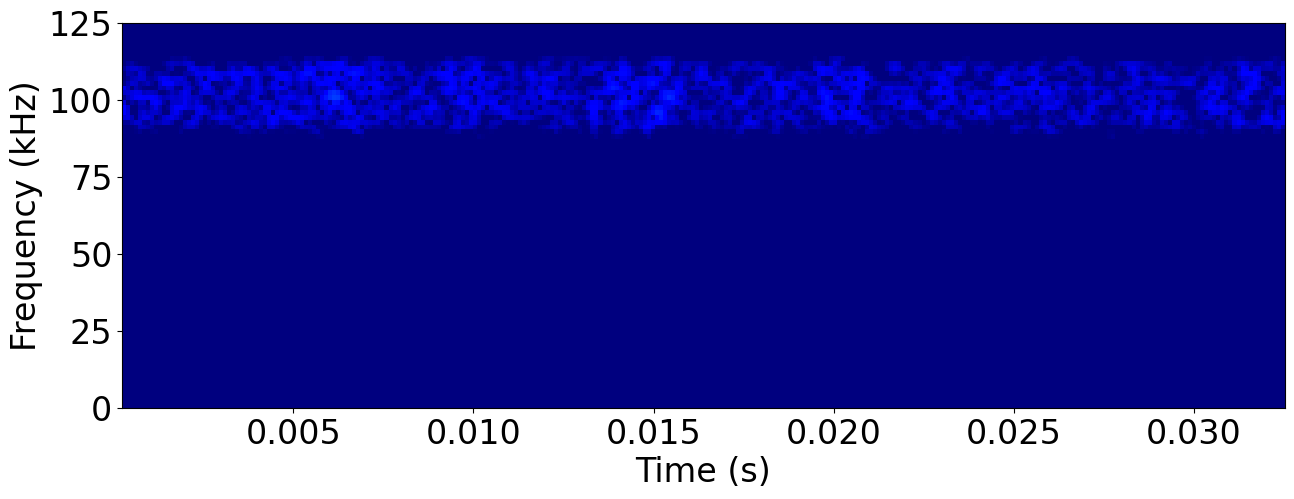

In [195]:
plt.figure(figsize=(15, 5))
plt.rcParams.update({'font.size': 24})
plt.specgram(snr_call_signal, NFFT=156, Fs=fs, cmap='jet', vmin=-120, vmax=0)
plt.yticks(ticks=np.linspace(0, fs/2, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
plt.ylabel("Frequency (kHz)")
plt.xlabel("Time (s)")
plt.show()

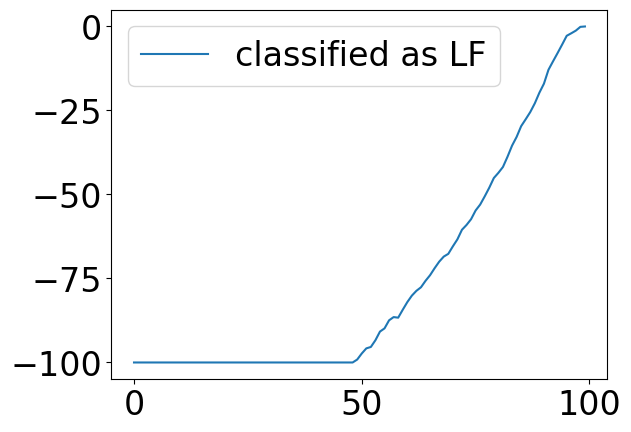

In [196]:
welch_key = 'all_locations'
output_dir = Path(f'{Path.home()}/duty-cycle-investigation/data/generated_welch/{welch_key}')
output_file_type = 'top1_inbouts_welch_signals'
welch_data = pd.read_csv(output_dir / f'2022_{welch_key}_{output_file_type}.csv', index_col=0, low_memory=False)
k = 2
kmean_welch = KMeans(n_clusters=k, n_init=10, random_state=1).fit(welch_data.values)
plt.plot(welch_signal.flatten(), label=f'classified as {LABEL_FOR_GROUPS[kmean_welch.predict(welch_signal)[0]]}')
plt.legend()
plt.show()

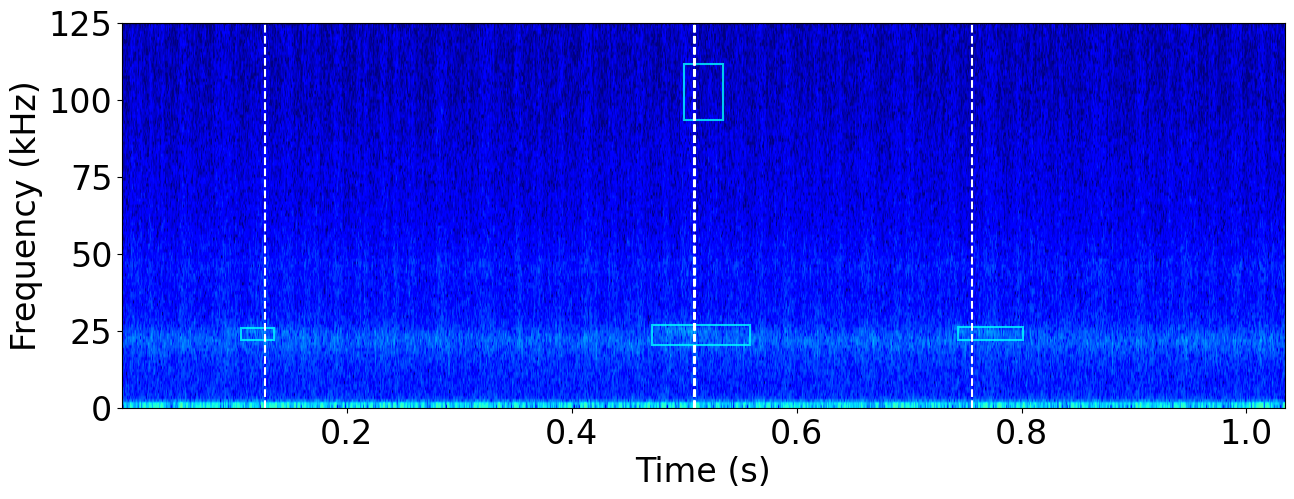

In [197]:
selection_row = selections.iloc[1]
input_file = Path(selection_row['input_file'])
file_name = input_file.name
file_path = Path(raventxt_human_files_dir) / file_name
audio_file = sf.SoundFile(file_path)
fs = audio_file.samplerate


raventxt_human_filename = f'{input_file.stem}_manually_verified_by_AK_with_groups'

snr_included_ravenpro_human_txt = pd.read_csv(f'{raventxt_human_files_dir}/{raventxt_human_filename}_ravenpro_SNR_aditya_SNR_and_peakfreqtime.txt', sep=sep)
bd2_human_df_file = snr_included_ravenpro_human_txt.copy()
bd2_human_df_file = bd2_human_df_file.drop(columns=['Selection', 'View', 'Channel'])
bd2_human_df_file.rename(columns={'Begin Time (s)':'start_time',
                            'End Time (s)':'end_time',
                            'Low Freq (Hz)':'low_freq',
                            'High Freq (Hz)':'high_freq',
                            'Delta Time (s)':'delta_time_s',
                            'Manually-Verified Phonic Group':'freq_group',
                            'SNR NIST Quick (dB)':'snr_nist_quick_dB'}, inplace=True)
bd2_human_df_file.sort_values('start_time', inplace=True)
bd2_human_df_file = bd2_human_df_file.reset_index(drop=True)

start = selection_row['start_time']-0.5
audio_file.seek(int(fs*(start)))
duration = (selection_row['end_time']-selection_row['start_time'])+1
audio_seg = audio_file.read(int(fs*duration))

plt.figure(figsize=(15, 5))
plt.rcParams.update({'font.size': 24})
plt.specgram(audio_seg, NFFT=256, Fs=fs, cmap='jet', vmin=-120, vmax=0)

ax = plt.gca()
plot_bd2dets = selections[(selections['start_time']>=start)&(selections['end_time']<=(start+duration))]
for i, row in plot_bd2dets.iterrows():
    rect = patches.Rectangle(((row['start_time'] - start), row['low_freq']), 
                    (row['end_time'] - row['start_time']), (row['high_freq'] - row['low_freq']), 
                    linewidth=1.5, edgecolor=FREQ_COLORS[row['freq_group']], facecolor='none', alpha=0.8)
    ax.add_patch(rect)
    ax.axvline(x=row['peak_frequency_time_SPECTROGRAM']-start, linestyle='dashed', color='w')

plot_humandets = bd2_human_df_file[(bd2_human_df_file['start_time']>=start)&(bd2_human_df_file['end_time']<=(start+duration))]
for i, row in plot_humandets.iterrows():
    rect = patches.Rectangle(((row['start_time'] - start), row['low_freq']), 
                    (row['end_time'] - row['start_time']), (row['high_freq'] - row['low_freq']), 
                    linewidth=1.5, edgecolor=FREQ_COLORS[row['freq_group']], facecolor='none', alpha=0.8)
    ax.add_patch(rect)
    ax.axvline(x=row['peak_frequency_time']-start, linestyle='dashed', color='w')

plt.yticks(ticks=np.linspace(0, fs/2, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
plt.ylabel("Frequency (kHz)")
plt.xlabel("Time (s)")
plt.show()

In [198]:
selection_row

freq_group                                                                        LF
peak_frequency_time_SPECTROGRAM                                          1429.820992
peak_frequency_SPECTROGRAM                                                  101562.5
peak_frequency_WELCH                                                         94080.0
SNR                                                                         0.681336
start_time                                                                 1429.8115
end_time                                                                   1429.8458
low_freq                                                                       93359
high_freq                                                                     111638
class                                                       Rhinolophus hipposideros
class_prob                                                                     0.027
det_prob                                                         

In [199]:
call_dur = (selection_row['end_time'] - selection_row['start_time'])
audio_seg, length_of_section, pad = get_section_of_call_in_file(selection_row, audio_file)
seg_start = selection_row['start_time'] - call_dur - (3*pad)

freq_pad = 2000
low_freq_cutoff = selection_row['low_freq']-freq_pad
high_freq_cutoff = min((fs//2)-1, selection_row['high_freq']+freq_pad)
band_limited_audio_seg = batdetect2_pipeline.bandpass_audio_signal(audio_seg, fs, low_freq_cutoff, high_freq_cutoff)

signal = band_limited_audio_seg.copy()
signal[:int(fs*(length_of_section))] = 0
noise = band_limited_audio_seg - signal
snr_call_signal = signal[-int(fs*length_of_section):]
snr_noise_signal = noise[:int(fs*length_of_section)]

snr = batdetect2_pipeline.get_snr_from_band_limited_signal(snr_call_signal, snr_noise_signal)

welch_info = dict()
welch_info['num_points'] = 100
max_visible_frequency = 96000
welch_info['max_freq_visible'] = max_visible_frequency
welch_signal = batdetect2_pipeline.compute_welch_psd_of_call(snr_call_signal, fs, welch_info)
# features_of_interest['welch_signals'].append(welch_signal)

peaks = np.where(welch_signal==max(welch_signal))[0][0]
# features_of_interest['peak_freqs_welch'].append(max_visible_frequency*(peaks/len(welch_signal)))

welch_signal = (welch_signal).reshape(1, len(welch_signal))
# features_of_interest['classes'].append(kmean_welch.predict(welch_signal)[0])

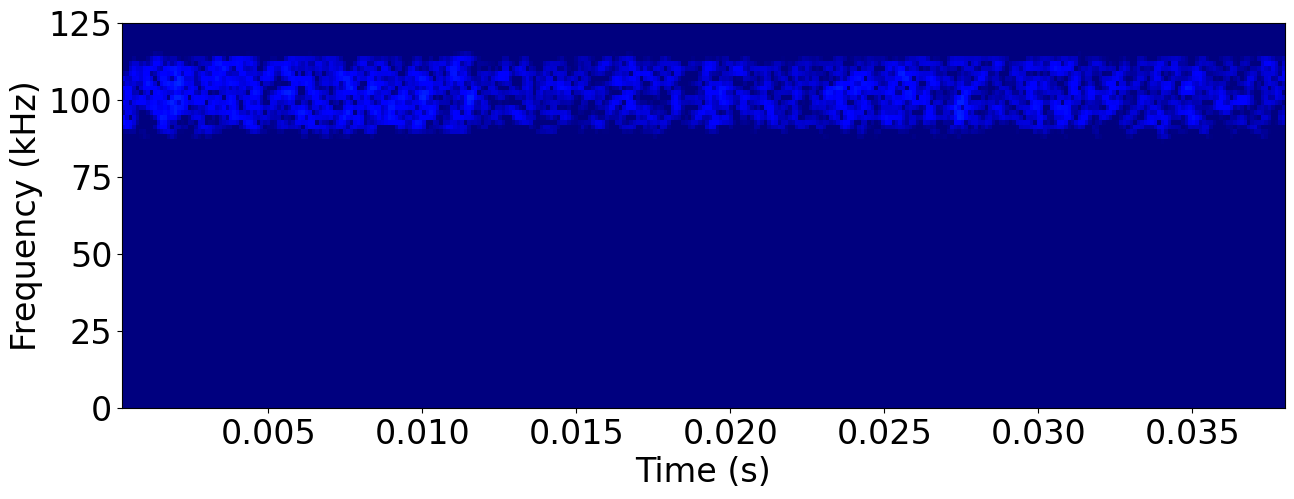

In [200]:
plt.figure(figsize=(15, 5))
plt.rcParams.update({'font.size': 24})
plt.specgram(snr_call_signal, NFFT=156, Fs=fs, cmap='jet', vmin=-120, vmax=0)
plt.yticks(ticks=np.linspace(0, fs/2, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
plt.ylabel("Frequency (kHz)")
plt.xlabel("Time (s)")
plt.show()

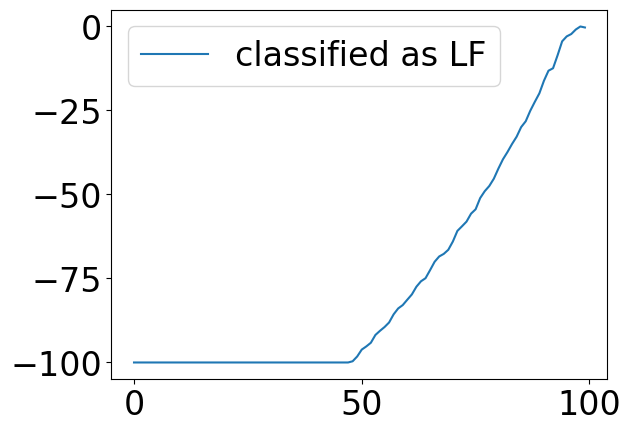

In [201]:
welch_key = 'all_locations'
output_dir = Path(f'{Path.home()}/duty-cycle-investigation/data/generated_welch/{welch_key}')
output_file_type = 'top1_inbouts_welch_signals'
welch_data = pd.read_csv(output_dir / f'2022_{welch_key}_{output_file_type}.csv', index_col=0, low_memory=False)
k = 2
kmean_welch = KMeans(n_clusters=k, n_init=10, random_state=1).fit(welch_data.values)
plt.plot(welch_signal.flatten(), label=f'classified as {LABEL_FOR_GROUPS[kmean_welch.predict(welch_signal)[0]]}')
plt.legend()
plt.show()

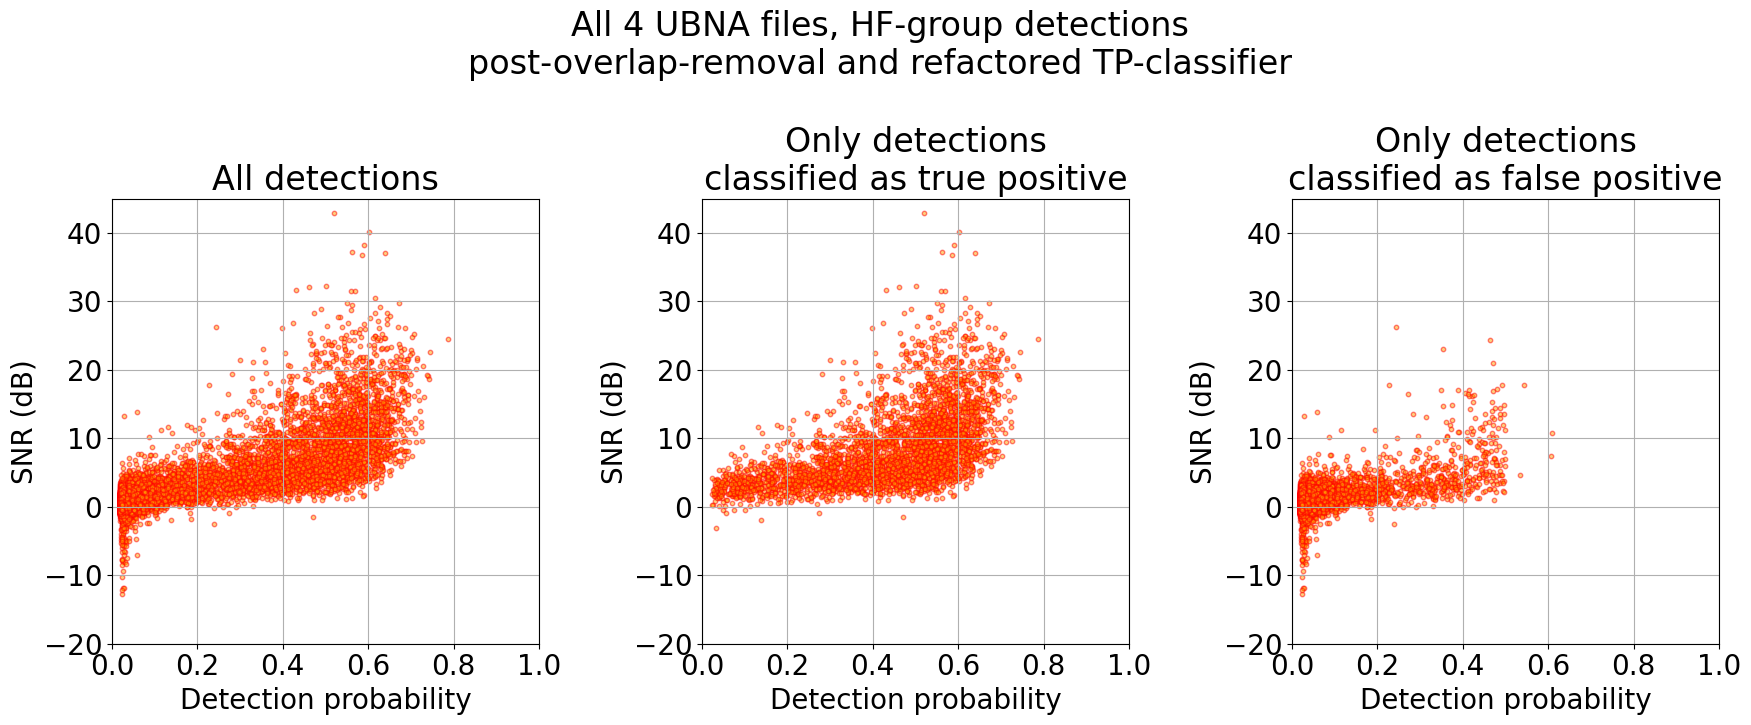

In [30]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18,7.5))
plt.rcParams.update({'font.size':20})

fig.suptitle(f'All 4 UBNA files, HF-group detections\npost-overlap-removal and refactored TP-classifier')

ax = ax1
ax.set_title(f'All detections')
ax.scatter(hf_all_files_batdetct2_df_reduced_overlaps['det_prob'].values, 
            hf_all_files_batdetct2_df_reduced_overlaps['SNR'].values,
            alpha=0.5, s=10, facecolor='orange', edgecolor='red')
ax.grid(which='both')
ax.set_xlabel('Detection probability')
ax.set_ylabel('SNR (dB)')
ax.set_xlim(0, 1.0)
ax.set_ylim(-20, 45.0)

ax = ax2
ax.set_title(f'Only detections\nclassified as true positive')
ax.scatter(hf_all_files_batdetct2_df_true_positives_reduced_overlaps['det_prob'].values, 
            hf_all_files_batdetct2_df_true_positives_reduced_overlaps['SNR'].values,
            alpha=0.5, s=10, facecolor='orange', edgecolor='red')
ax.grid(which='both')
ax.set_xlabel('Detection probability')
ax.set_ylabel('SNR (dB)')
ax.set_xlim(0, 1.0)
ax.set_ylim(-20, 45.0)

ax = ax3
ax.set_title(f'Only detections\nclassified as false positive')
ax.scatter(hf_all_files_batdetct2_df_false_positives_reduced_overlaps['det_prob'].values, 
            hf_all_files_batdetct2_df_false_positives_reduced_overlaps['SNR'].values,
            alpha=0.5, s=10, facecolor='orange', edgecolor='red')
ax.grid(which='both')
ax.set_xlabel('Detection probability')
ax.set_ylabel('SNR (dB)')
ax.set_xlim(0, 1.0)
ax.set_ylim(-20, 45.0)


fig.tight_layout()
plt.show()

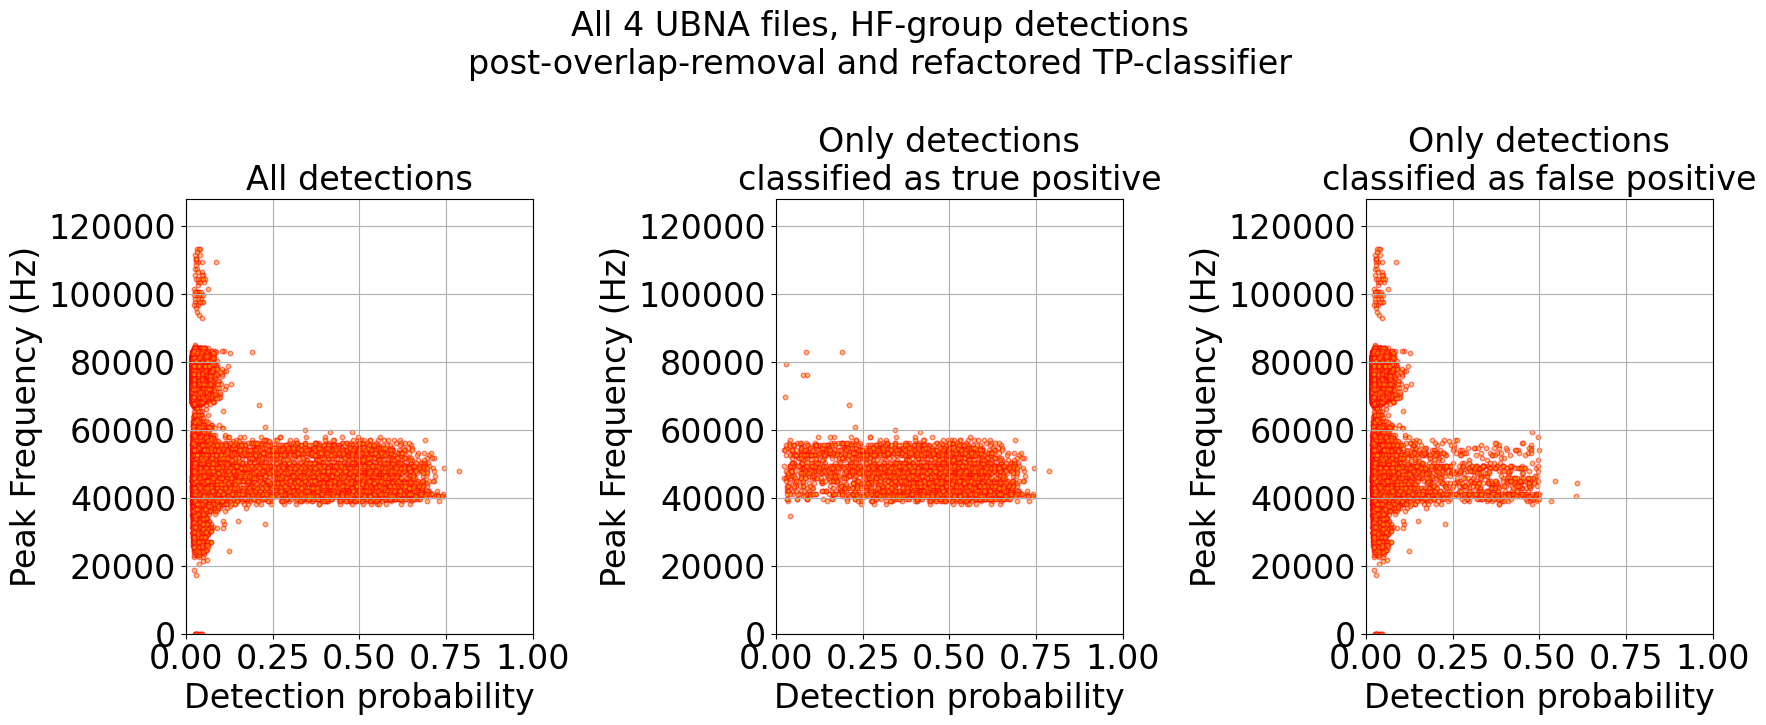

In [202]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18,7.5))
plt.rcParams.update({'font.size':20})

fig.suptitle(f'All 4 UBNA files, HF-group detections\npost-overlap-removal and refactored TP-classifier')

ax = ax1
ax.set_title(f'All detections')
ax.scatter(hf_all_files_batdetct2_df_reduced_overlaps['det_prob'].values, 
            hf_all_files_batdetct2_df_reduced_overlaps['peak_frequency_SPECTROGRAM'].values,
            alpha=0.5, s=10, facecolor='orange', edgecolor='red')
ax.grid(which='both')
ax.set_xlabel('Detection probability')
ax.set_ylabel('Peak Frequency (Hz)')
ax.set_xlim(0, 1.0)
ax.set_ylim(0, 128000)

ax = ax2
ax.set_title(f'Only detections\nclassified as true positive')
ax.scatter(hf_all_files_batdetct2_df_true_positives_reduced_overlaps['det_prob'].values, 
            hf_all_files_batdetct2_df_true_positives_reduced_overlaps['peak_frequency_SPECTROGRAM'].values,
            alpha=0.5, s=10, facecolor='orange', edgecolor='red')
ax.grid(which='both')
ax.set_xlabel('Detection probability')
ax.set_ylabel('Peak Frequency (Hz)')
ax.set_xlim(0, 1.0)
ax.set_ylim(0, 128000)

ax = ax3
ax.set_title(f'Only detections\nclassified as false positive')
ax.scatter(hf_all_files_batdetct2_df_false_positives_reduced_overlaps['det_prob'].values, 
            hf_all_files_batdetct2_df_false_positives_reduced_overlaps['peak_frequency_SPECTROGRAM'].values,
            alpha=0.5, s=10, facecolor='orange', edgecolor='red')
ax.grid(which='both')
ax.set_xlabel('Detection probability')
ax.set_ylabel('Peak Frequency (Hz)')
ax.set_xlim(0, 1.0)
ax.set_ylim(0, 128000)


fig.tight_layout()
plt.show()

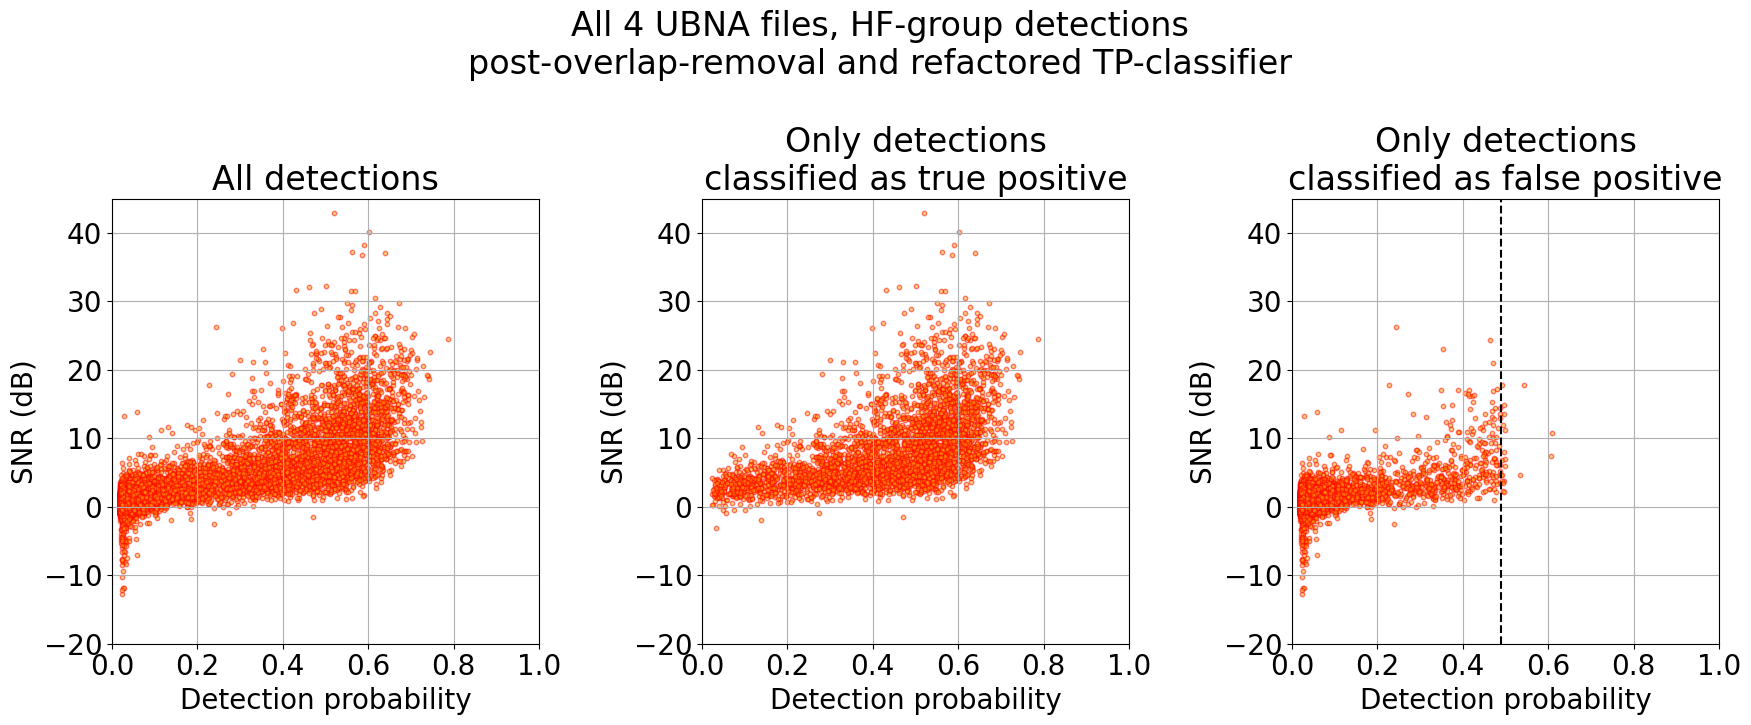

In [207]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18,7.5))
plt.rcParams.update({'font.size':20})

fig.suptitle(f'All 4 UBNA files, HF-group detections\npost-overlap-removal and refactored TP-classifier')

ax = ax1
ax.set_title(f'All detections')
ax.scatter(hf_all_files_batdetct2_df_reduced_overlaps['det_prob'].values, 
            hf_all_files_batdetct2_df_reduced_overlaps['SNR'].values,
            alpha=0.5, s=10, facecolor='orange', edgecolor='red')
ax.grid(which='both')
ax.set_xlabel('Detection probability')
ax.set_ylabel('SNR (dB)')
ax.set_xlim(0, 1.0)
ax.set_ylim(-20, 45.0)

ax = ax2
ax.set_title(f'Only detections\nclassified as true positive')
ax.scatter(hf_all_files_batdetct2_df_true_positives_reduced_overlaps['det_prob'].values, 
            hf_all_files_batdetct2_df_true_positives_reduced_overlaps['SNR'].values,
            alpha=0.5, s=10, facecolor='orange', edgecolor='red')
ax.grid(which='both')
ax.set_xlabel('Detection probability')
ax.set_ylabel('SNR (dB)')
ax.set_xlim(0, 1.0)
ax.set_ylim(-20, 45.0)

ax = ax3
ax.set_title(f'Only detections\nclassified as false positive')
ax.scatter(hf_all_files_batdetct2_df_false_positives_reduced_overlaps['det_prob'].values, 
            hf_all_files_batdetct2_df_false_positives_reduced_overlaps['SNR'].values,
            alpha=0.5, s=10, facecolor='orange', edgecolor='red')
ax.axvline(x=0.49, linestyle='dashed', color='k')
ax.grid(which='both')
ax.set_xlabel('Detection probability')
ax.set_ylabel('SNR (dB)')
ax.set_xlim(0, 1.0)
ax.set_ylim(-20, 45.0)


fig.tight_layout()
plt.show()

In [219]:
selections = hf_all_files_batdetct2_df_false_positives_reduced_overlaps[hf_all_files_batdetct2_df_false_positives_reduced_overlaps['det_prob']>0.49]
selections

,freq_group,peak_frequency_time_SPECTROGRAM,peak_frequency_SPECTROGRAM,peak_frequency_WELCH,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file
11325,HF,245.452133,39000.0,40320.0,2.253914,245.4475,245.4562,39218,44561,Pipistrellus nathusii,0.467,0.494,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
14963,HF,318.897967,46500.0,45120.0,17.743159,318.8915,318.9007,43515,60885,Pipistrellus pipistrellus,0.326,0.493,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
59922,HF,1284.121333,41250.0,42240.0,2.128125,1284.1145,1284.1245,40937,48464,Pipistrellus nathusii,0.462,0.497,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
14259,HF,264.567033,51000.0,49920.0,3.739258,264.5655,264.5703,48671,55872,Pipistrellus pipistrellus,0.360,0.496,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
16061,HF,298.029100,48000.0,48000.0,13.601251,298.0245,298.0309,46953,60539,Pipistrellus pipistrellus,0.300,0.496,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
18928,HF,349.360767,41250.0,41280.0,5.976319,349.3565,349.3644,39218,51048,Pipistrellus nathusii,0.397,0.498,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
24670,HF,456.278600,41250.0,41280.0,6.864920,456.2755,456.2834,39218,49630,Pipistrellus nathusii,0.462,0.493,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
72293,HF,1426.496867,45000.0,39360.0,8.024529,1426.4945,1426.5043,40078,46193,Pipistrellus nathusii,0.479,0.496,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
72322,HF,1426.943033,39750.0,39360.0,7.042949,1426.9365,1426.9468,38359,47867,Pipistrellus nathusii,0.469,0.498,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
74573,HF,1465.773233,57750.0,58560.0,14.850908,1465.7705,1465.7776,45234,69034,Pipistrellus pipistrellus,0.280,0.496,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...


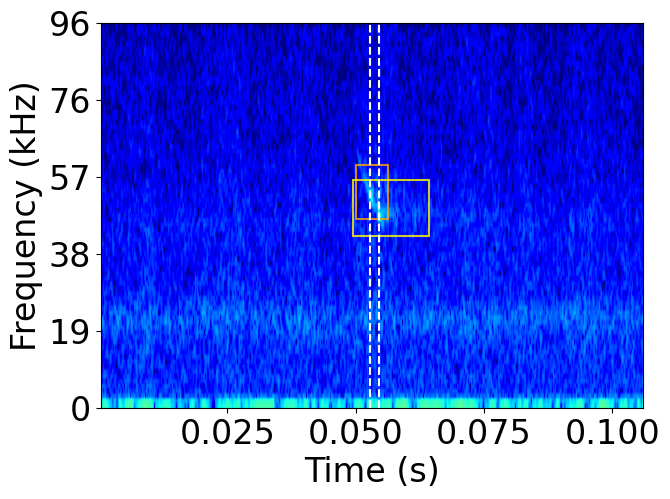

In [246]:
selection_row = selections.iloc[4]
input_file = Path(selection_row['input_file'])
file_name = input_file.name
file_path = Path(raventxt_human_files_dir) / file_name
audio_file = sf.SoundFile(file_path)
fs = audio_file.samplerate

file_selections = selections[selections['input_file']==str(input_file)]
file_true_positives = hf_all_files_batdetct2_df_true_positives_reduced_overlaps[hf_all_files_batdetct2_df_true_positives_reduced_overlaps['input_file']==str(input_file)]
raventxt_human_filename = f'{input_file.stem}_manually_verified_by_AK_with_groups'

snr_included_ravenpro_human_txt = pd.read_csv(f'{raventxt_human_files_dir}/{raventxt_human_filename}_ravenpro_SNR_aditya_SNR_and_peakfreqtime.txt', sep=sep)
bd2_human_df_file = snr_included_ravenpro_human_txt.copy()
bd2_human_df_file = bd2_human_df_file.drop(columns=['Selection', 'View', 'Channel'])
bd2_human_df_file.rename(columns={'Begin Time (s)':'start_time',
                            'End Time (s)':'end_time',
                            'Low Freq (Hz)':'low_freq',
                            'High Freq (Hz)':'high_freq',
                            'Delta Time (s)':'delta_time_s',
                            'Manually-Verified Phonic Group':'freq_group',
                            'SNR NIST Quick (dB)':'snr_nist_quick_dB'}, inplace=True)
bd2_human_df_file.sort_values('start_time', inplace=True)
bd2_human_df_file = bd2_human_df_file.reset_index(drop=True)

start = selection_row['start_time']-0.05
audio_file.seek(int(fs*(start)))
duration = (selection_row['end_time']-selection_row['start_time'])+0.1
audio_seg = audio_file.read(int(fs*duration))

plt.figure(figsize=(7, 5))
plt.rcParams.update({'font.size': 24})
plt.specgram(audio_seg, NFFT=156, Fs=fs, cmap='jet', vmin=-120, vmax=0)

ax = plt.gca()
plot_bd2fpdets = file_selections[(file_selections['start_time']>=start)&(file_selections['end_time']<=(start+duration))]
for i, row in plot_bd2fpdets.iterrows():
    rect = patches.Rectangle(((row['start_time'] - start), row['low_freq']), 
                    (row['end_time'] - row['start_time']), (row['high_freq'] - row['low_freq']), 
                    linewidth=1.5, edgecolor=FREQ_COLORS[row['freq_group']], facecolor='none', alpha=0.8)
    ax.add_patch(rect)
    ax.axvline(x=row['peak_frequency_time_SPECTROGRAM']-start, linestyle='dashed', color='w')

plot_humandets = bd2_human_df_file[(bd2_human_df_file['start_time']>=start)&(bd2_human_df_file['end_time']<=(start+duration))]
for i, row in plot_humandets.iterrows():
    rect = patches.Rectangle(((row['start_time'] - start), row['low_freq']), 
                    (row['end_time'] - row['start_time']), (row['high_freq'] - row['low_freq']), 
                    linewidth=1.5, edgecolor='yellow', facecolor='none', alpha=0.8)
    ax.add_patch(rect)
    ax.axvline(x=row['peak_frequency_time']-start, linestyle='dashed', color='w')

plot_bd2tpdets = file_true_positives[(file_true_positives['start_time']>=start)&(file_true_positives['end_time']<=(start+duration))]
for i, row in plot_bd2tpdets.iterrows():
    rect = patches.Rectangle(((row['start_time'] - start), row['low_freq']), 
                    (row['end_time'] - row['start_time']), (row['high_freq'] - row['low_freq']), 
                    linewidth=1.5, edgecolor='green', facecolor='none', alpha=0.8)
    ax.add_patch(rect)
    ax.axvline(x=row['peak_frequency_time_SPECTROGRAM']-start, linestyle='dashed', color='w')

plt.yticks(ticks=np.linspace(0, fs/2, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
plt.ylabel("Frequency (kHz)")
plt.xlabel("Time (s)")
plt.show()

In [240]:
plot_humandets

,start_time,end_time,low_freq,high_freq,snr_nist_quick_dB,class,class_prob,det_prob,individual,Annotation,input_file,Site name,Recover Folder,SD Card,confidency,freq_group,Annotation.1,adityas_method_snr_dB,peak_frequency_time
52,245.441638,245.458928,34666.667,49333.333,11.54,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,HF,AK_echolocation,1.235938,245.450515


In [241]:
plot_bd2fpdets

,freq_group,peak_frequency_time_SPECTROGRAM,peak_frequency_SPECTROGRAM,peak_frequency_WELCH,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file
11325,HF,245.452133,39000.0,40320.0,2.253914,245.4475,245.4562,39218,44561,Pipistrellus nathusii,0.467,0.494,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...


In [99]:
def return_confusion_matrix_from_comparing_two_detectors(human_df, machine_df):
    dist_matrix = np.zeros((len(machine_df), len(human_df)))
    association_matrix = np.zeros((len(machine_df), len(human_df)), dtype='bool')
    for index in range(len(machine_df)):
        batdetect2_row = machine_df.iloc[index]
        dist_to_all_calls = ((human_df['peak_frequency_time'] - batdetect2_row['peak_frequency_time_SPECTROGRAM']).values)
        dist_matrix[index,:] = dist_to_all_calls
    
        dist_to_all_calls[np.abs(dist_to_all_calls)>=0.001] = 1
        dist_to_all_calls[np.abs(dist_to_all_calls)<0.001] = 0
        association_matrix[index,:] = ~dist_to_all_calls.astype('bool')

    human_bd2_true_positives = human_df.loc[np.logical_or.reduce(association_matrix, axis=0)]
    bd2_false_negatives = human_df.loc[~(np.logical_or.reduce(association_matrix, axis=0))]
    bd2_true_positives = machine_df.loc[np.logical_or.reduce(association_matrix, axis=1)]
    bd2_false_positives = machine_df.loc[~(np.logical_or.reduce(association_matrix, axis=1))]

    return {'true_positives':len(bd2_true_positives), 
            'false_positives':len(bd2_false_positives), 
            'false_negatives':len(bd2_false_negatives), 
            'true_negatives':0}

def get_precision_and_recall_from_metrics(true_positives, false_positives, false_negatives):
    denom_precision = (true_positives + false_positives)
    denom_recall = (true_positives + false_negatives)
    if (denom_precision>0):
        precision = true_positives / denom_precision
    else:
        precision = np.NaN
    if (denom_recall>0):
        recall = true_positives / denom_recall
    else:
        recall = np.NaN
    
    return precision, recall

def gather_evaluation_results_between_bd2_and_human(bd2_human_df, batdetect2_df_thresh):
    file_batdetect2_cf = return_confusion_matrix_from_comparing_two_detectors(bd2_human_df, batdetect2_df_thresh)
    precision, recall = get_precision_and_recall_from_metrics(file_batdetect2_cf['true_positives'], 
                                                              file_batdetect2_cf['false_positives'], 
                                                              file_batdetect2_cf['false_negatives'])

    return file_batdetect2_cf, precision, recall

def apply_SNR_threshold_on_both_sets(bd2_human_df, batdetect2_df, SNR_thresh):
    bd2_human_df_SNR = bd2_human_df[bd2_human_df['adityas_method_snr_dB']>=SNR_thresh].copy()
    batdetect2_df_SNR = batdetect2_df[batdetect2_df['SNR']>=SNR_thresh].copy()

    return bd2_human_df_SNR, batdetect2_df_SNR

def make_new_row_in_eval_df(file_batdetect2_cf, precision, recall):
    row = pd.DataFrame([file_batdetect2_cf])
    row['precision'] = precision
    row['recall'] = recall

    return row

def generate_evaluation_df(bd2_human_df, batdetect2_df):
    batdetect2_eval = pd.DataFrame()

    increment = 2.0
    snr_thresholds = np.arange(0, 22, increment)
    for snr_thresh in snr_thresholds:
        bd2_human_df_SNR, batdetect2_df_SNR = apply_SNR_threshold_on_both_sets(bd2_human_df, batdetect2_df, snr_thresh)

        increment = 0.01
        detection_thresholds = np.arange(0.01, 0.6+increment, increment)
        for det_thresh in detection_thresholds:
            det_thresh = round(det_thresh, 2)
            print(snr_thresh, det_thresh)
            batdetect2_df_SNR_detthresh = batdetect2_df_SNR[batdetect2_df_SNR['det_prob']>=det_thresh].copy()
            file_batdetect2_cf, precision, recall = gather_evaluation_results_between_bd2_and_human(bd2_human_df_SNR, 
                                                                                                    batdetect2_df_SNR_detthresh)
            row = make_new_row_in_eval_df(file_batdetect2_cf, precision, recall)
            row.insert(0, 'num_human_annotations', [len(bd2_human_df_SNR)])
            row.insert(0, 'num_bd2_detections', [len(batdetect2_df_SNR_detthresh)])
            row.insert(0, 'detection_threshold', [det_thresh])
            row.insert(0, 'SNR_threshold', [snr_thresh])
            batdetect2_eval = pd.concat([batdetect2_eval, row])
            assert(len(batdetect2_df_SNR_detthresh['freq_group'].unique())<=2)

    batdetect2_eval.reset_index(drop=True, inplace=True)
    return batdetect2_eval

In [94]:
batdetect2_eval = pd.DataFrame()
batdetect2_eval_LF = pd.DataFrame()
batdetect2_eval_HF = pd.DataFrame()

file_key = '20220826_070000'
wav_filename = file_key
site = file_sites[file_key]
plot_file = Path(f'{raventxt_human_files_dir}/{wav_filename}.WAV')
raventxt_human_filename = f'{wav_filename}_manually_verified_by_AK_with_groups'

snr_included_ravenpro_human_txt = pd.read_csv(f'{raventxt_human_files_dir}/{raventxt_human_filename}_ravenpro_SNR_aditya_SNR_and_peakfreqtime.txt', sep=sep)
bd2_human_df_file = snr_included_ravenpro_human_txt.copy()
bd2_human_df_file = bd2_human_df_file.drop(columns=['Selection', 'View', 'Channel'])
bd2_human_df_file.rename(columns={'Begin Time (s)':'start_time',
                            'End Time (s)':'end_time',
                            'Low Freq (Hz)':'low_freq',
                            'High Freq (Hz)':'high_freq',
                            'Delta Time (s)':'delta_time_s',
                            'Manually-Verified Phonic Group':'freq_group',
                            'SNR NIST Quick (dB)':'snr_nist_quick_dB'}, inplace=True)
bd2_human_df_file.sort_values('start_time', inplace=True)

args = dict()
args['chunk_size'] = 2
args['detection_threshold'] = 0.00
ones = int(args['detection_threshold'])
decimals = int(int(100*(args['detection_threshold'])) % 100)
threshold_tag = f"threshold{ones}p{decimals:02}"
save_loc_reduced_overlaps = Path(f"bd2__{threshold_tag}_chunksize{int(args['chunk_size'])}_{wav_filename}_REDUCED_OVERLAPS.csv")
filepath_reduced_overlaps = bd2_dets_save_dir / save_loc_reduced_overlaps
batdetect2_df_file_reduced_overlaps = pd.read_csv(filepath_reduced_overlaps, sep=',', index_col=0)
batdetect2_df_file_reduced_overlaps.rename(columns={'KMEANS_CLASSES':'freq_group'}, inplace=True)

batdetect2_eval_file = generate_evaluation_df(bd2_human_df_file, batdetect2_df_file_reduced_overlaps)
batdetect2_eval_file['input_file_name'] = [f'{wav_filename}.WAV']*len(batdetect2_eval_file)
batdetect2_eval_file['site_name'] = [SITE_NAMES[site]]*len(batdetect2_eval_file)

bd2_human_df_file_LF = bd2_human_df_file[bd2_human_df_file['freq_group']=='LF'].copy()
batdetect2_df_file_LF_reduced_overlaps = batdetect2_df_file_reduced_overlaps[batdetect2_df_file_reduced_overlaps['freq_group']=='LF'].copy()
batdetect2_eval_file_LF = generate_evaluation_df(bd2_human_df_file_LF, batdetect2_df_file_LF_reduced_overlaps)
batdetect2_eval_file_LF['input_file_name'] = [f'{wav_filename}.WAV']*len(batdetect2_eval_file_LF)
batdetect2_eval_file_LF['site_name'] = [SITE_NAMES[site]]*len(batdetect2_eval_file_LF)

bd2_human_df_file_HF = bd2_human_df_file[bd2_human_df_file['freq_group']=='HF'].copy()
batdetect2_df_file_HF_reduced_overlaps = batdetect2_df_file_reduced_overlaps[batdetect2_df_file_reduced_overlaps['freq_group']=='HF'].copy()
batdetect2_eval_file_HF = generate_evaluation_df(bd2_human_df_file_HF, batdetect2_df_file_HF_reduced_overlaps)
batdetect2_eval_file_HF['input_file_name'] = [f'{wav_filename}.WAV']*len(batdetect2_eval_file_HF)
batdetect2_eval_file_HF['site_name'] = [SITE_NAMES[site]]*len(batdetect2_eval_file_HF)

0.0 0.01
0.0 0.02
0.0 0.03
0.0 0.04
0.0 0.05
0.0 0.06
0.0 0.07
0.0 0.08
0.0 0.09
0.0 0.1
0.0 0.11
0.0 0.12
0.0 0.13
0.0 0.14
0.0 0.15
0.0 0.16
0.0 0.17
0.0 0.18
0.0 0.19
0.0 0.2
0.0 0.21
0.0 0.22
0.0 0.23
0.0 0.24
0.0 0.25
0.0 0.26
0.0 0.27
0.0 0.28
0.0 0.29
0.0 0.3
0.0 0.31
0.0 0.32
0.0 0.33
0.0 0.34
0.0 0.35
0.0 0.36
0.0 0.37
0.0 0.38
0.0 0.39
0.0 0.4
0.0 0.41
0.0 0.42
0.0 0.43
0.0 0.44
0.0 0.45
0.0 0.46
0.0 0.47
0.0 0.48
0.0 0.49
0.0 0.5
0.0 0.51
0.0 0.52
0.0 0.53
0.0 0.54
0.0 0.55
0.0 0.56
0.0 0.57
0.0 0.58
0.0 0.59
0.0 0.6
5.0 0.01
5.0 0.02
5.0 0.03
5.0 0.04
5.0 0.05
5.0 0.06
5.0 0.07
5.0 0.08
5.0 0.09
5.0 0.1
5.0 0.11
5.0 0.12
5.0 0.13
5.0 0.14
5.0 0.15
5.0 0.16
5.0 0.17
5.0 0.18
5.0 0.19
5.0 0.2
5.0 0.21
5.0 0.22
5.0 0.23
5.0 0.24
5.0 0.25
5.0 0.26
5.0 0.27
5.0 0.28
5.0 0.29
5.0 0.3
5.0 0.31
5.0 0.32
5.0 0.33
5.0 0.34
5.0 0.35
5.0 0.36
5.0 0.37
5.0 0.38
5.0 0.39
5.0 0.4
5.0 0.41
5.0 0.42
5.0 0.43
5.0 0.44
5.0 0.45
5.0 0.46
5.0 0.47
5.0 0.48
5.0 0.49
5.0 0.5
5.0 0.51
5.0 0.52
5.0

In [96]:
batdetect2_eval_file_LF[batdetect2_eval_file_LF['SNR_threshold']==0.0][1::2]

,SNR_threshold,detection_threshold,num_bd2_detections,num_human_annotations,true_positives,false_positives,false_negatives,true_negatives,precision,recall,input_file_name,site_name
1,0.0,0.02,27256,1100,734,26522,366,0,0.026930,0.667273,20220826_070000.WAV,Central Pond
3,0.0,0.04,3985,1100,719,3266,381,0,0.180427,0.653636,20220826_070000.WAV,Central Pond
5,0.0,0.06,2113,1100,707,1406,393,0,0.334595,0.642727,20220826_070000.WAV,Central Pond
7,0.0,0.08,1546,1100,695,851,405,0,0.449547,0.631818,20220826_070000.WAV,Central Pond
9,0.0,0.10,1276,1100,688,588,412,0,0.539185,0.625455,20220826_070000.WAV,Central Pond
11,0.0,0.12,1152,1100,678,474,422,0,0.588542,0.616364,20220826_070000.WAV,Central Pond
13,0.0,0.14,1079,1100,668,411,432,0,0.619092,0.607273,20220826_070000.WAV,Central Pond
15,0.0,0.16,1034,1100,662,372,438,0,0.640232,0.601818,20220826_070000.WAV,Central Pond
17,0.0,0.18,980,1100,647,333,453,0,0.660204,0.588182,20220826_070000.WAV,Central Pond
19,0.0,0.20,938,1100,638,300,462,0,0.680171,0.580000,20220826_070000.WAV,Central Pond


In [100]:
batdetect2_eval = pd.DataFrame()
batdetect2_eval_LF = pd.DataFrame()
batdetect2_eval_HF = pd.DataFrame()
for file_key in file_keys:
    wav_filename = file_key
    site = file_sites[file_key]
    plot_file = Path(f'{raventxt_human_files_dir}/{wav_filename}.WAV')
    raventxt_human_filename = f'{wav_filename}_manually_verified_by_AK_with_groups'

    snr_included_ravenpro_human_txt = pd.read_csv(f'{raventxt_human_files_dir}/{raventxt_human_filename}_ravenpro_SNR_aditya_SNR_and_peakfreqtime.txt', sep=sep)
    bd2_human_df_file = snr_included_ravenpro_human_txt.copy()
    bd2_human_df_file = bd2_human_df_file.drop(columns=['Selection', 'View', 'Channel'])
    bd2_human_df_file.rename(columns={'Begin Time (s)':'start_time',
                                'End Time (s)':'end_time',
                                'Low Freq (Hz)':'low_freq',
                                'High Freq (Hz)':'high_freq',
                                'Delta Time (s)':'delta_time_s',
                                'Manually-Verified Phonic Group':'freq_group',
                                'SNR NIST Quick (dB)':'snr_nist_quick_dB'}, inplace=True)
    bd2_human_df_file.sort_values('start_time', inplace=True)

    args = dict()
    args['chunk_size'] = 2
    args['detection_threshold'] = 0.00
    ones = int(args['detection_threshold'])
    decimals = int(int(100*(args['detection_threshold'])) % 100)
    threshold_tag = f"threshold{ones}p{decimals:02}"
    save_loc_reduced_overlaps = Path(f"bd2__{threshold_tag}_chunksize{int(args['chunk_size'])}_{wav_filename}_REDUCED_OVERLAPS.csv")
    filepath_reduced_overlaps = bd2_dets_save_dir / save_loc_reduced_overlaps
    batdetect2_df_file_reduced_overlaps = pd.read_csv(filepath_reduced_overlaps, sep=',', index_col=0)
    batdetect2_df_file_reduced_overlaps.rename(columns={'KMEANS_CLASSES':'freq_group'}, inplace=True)

    batdetect2_eval_file = generate_evaluation_df(bd2_human_df_file, batdetect2_df_file_reduced_overlaps)
    batdetect2_eval_file['input_file_name'] = [f'{wav_filename}.WAV']*len(batdetect2_eval_file)
    batdetect2_eval_file['site_name'] = [SITE_NAMES[site]]*len(batdetect2_eval_file)

    bd2_human_df_file_LF = bd2_human_df_file[bd2_human_df_file['freq_group']=='LF'].copy()
    batdetect2_df_file_LF_reduced_overlaps = batdetect2_df_file_reduced_overlaps[batdetect2_df_file_reduced_overlaps['freq_group']=='LF'].copy()
    batdetect2_eval_file_LF = generate_evaluation_df(bd2_human_df_file_LF, batdetect2_df_file_LF_reduced_overlaps)
    batdetect2_eval_file_LF['input_file_name'] = [f'{wav_filename}.WAV']*len(batdetect2_eval_file_LF)
    batdetect2_eval_file_LF['site_name'] = [SITE_NAMES[site]]*len(batdetect2_eval_file_LF)

    bd2_human_df_file_HF = bd2_human_df_file[bd2_human_df_file['freq_group']=='HF'].copy()
    batdetect2_df_file_HF_reduced_overlaps = batdetect2_df_file_reduced_overlaps[batdetect2_df_file_reduced_overlaps['freq_group']=='HF'].copy()
    batdetect2_eval_file_HF = generate_evaluation_df(bd2_human_df_file_HF, batdetect2_df_file_HF_reduced_overlaps)
    batdetect2_eval_file_HF['input_file_name'] = [f'{wav_filename}.WAV']*len(batdetect2_eval_file_HF)
    batdetect2_eval_file_HF['site_name'] = [SITE_NAMES[site]]*len(batdetect2_eval_file_HF)

    batdetect2_eval = pd.concat([batdetect2_eval, batdetect2_eval_file])
    batdetect2_eval_LF = pd.concat([batdetect2_eval_LF, batdetect2_eval_file_LF])
    batdetect2_eval_HF = pd.concat([batdetect2_eval_HF, batdetect2_eval_file_HF])

0.0 0.01
0.0 0.02
0.0 0.03
0.0 0.04
0.0 0.05
0.0 0.06
0.0 0.07
0.0 0.08
0.0 0.09
0.0 0.1
0.0 0.11
0.0 0.12
0.0 0.13
0.0 0.14
0.0 0.15
0.0 0.16
0.0 0.17
0.0 0.18
0.0 0.19
0.0 0.2
0.0 0.21
0.0 0.22
0.0 0.23
0.0 0.24
0.0 0.25
0.0 0.26
0.0 0.27
0.0 0.28
0.0 0.29
0.0 0.3
0.0 0.31
0.0 0.32
0.0 0.33
0.0 0.34
0.0 0.35
0.0 0.36
0.0 0.37
0.0 0.38
0.0 0.39
0.0 0.4
0.0 0.41
0.0 0.42
0.0 0.43
0.0 0.44
0.0 0.45
0.0 0.46
0.0 0.47
0.0 0.48
0.0 0.49
0.0 0.5
0.0 0.51
0.0 0.52
0.0 0.53
0.0 0.54
0.0 0.55
0.0 0.56
0.0 0.57
0.0 0.58
0.0 0.59
0.0 0.6
2.0 0.01
2.0 0.02
2.0 0.03
2.0 0.04
2.0 0.05
2.0 0.06
2.0 0.07
2.0 0.08
2.0 0.09
2.0 0.1
2.0 0.11
2.0 0.12
2.0 0.13
2.0 0.14
2.0 0.15
2.0 0.16
2.0 0.17
2.0 0.18
2.0 0.19
2.0 0.2
2.0 0.21
2.0 0.22
2.0 0.23
2.0 0.24
2.0 0.25
2.0 0.26
2.0 0.27
2.0 0.28
2.0 0.29
2.0 0.3
2.0 0.31
2.0 0.32
2.0 0.33
2.0 0.34
2.0 0.35
2.0 0.36
2.0 0.37
2.0 0.38
2.0 0.39
2.0 0.4
2.0 0.41
2.0 0.42
2.0 0.43
2.0 0.44
2.0 0.45
2.0 0.46
2.0 0.47
2.0 0.48
2.0 0.49
2.0 0.5
2.0 0.51
2.0 0.52
2.0

In [101]:
batdetect2_eval.to_csv(bd2_dets_save_dir / '20250123__bd2_eval_results_per_thresh_and_file.csv')
batdetect2_eval_LF.to_csv(bd2_dets_save_dir / '20250123__bd2_LFeval_results_per_thresh_and_file.csv')
batdetect2_eval_HF.to_csv(bd2_dets_save_dir / '20250123__bd2_HFeval_results_per_thresh_and_file.csv')